# Bank Account Fraud – EDA và Xử lý Dữ liệu Khuyết

**Môn học:** Phân tích và Trực quan hóa Dữ liệu (CO5177)  
**Giảng viên hướng dẫn:** Thầy Lê Thành Sách  
**Học kỳ:** HK261 (Năm học 2026 – 2027)  

---

## Giới thiệu

Notebook này tập trung vào **EDA (Phân tích khám phá dữ liệu)** và **xử lý dữ liệu khuyết** cho bộ dữ liệu Bank Account Fraud (BAF) – Base.csv: 1.000.000 hồ sơ, 32 cột, nhãn raud_bool.

**Phạm vi notebook này:**
1. Chuẩn bị dữ liệu – nạp, kiểm tra, phân loại cột
2. Dữ liệu khuyết – phát hiện missing ẩn, tạo cờ, kiểm tra tín hiệu
3. Chia dữ liệu theo thời gian (Temporal Split) ← **thực hiện TRƯỚC EDA chi tiết**
4. Khám phá từng nhóm biến
5. Nhân khẩu học và tính công bằng

> **Lưu ý quan trọng:** Split được thực hiện ở Phần 3, trước mọi phân tích thống kê có dùng nhãn. Phần 4–5 chạy EDA mô tả trên toàn bộ data (được phép). Mọi thứ .fit() (scaler, imputer, encoder) chỉ fit trên df_train.

**Tài liệu tham khảo**
1. Bài báo gốc NeurIPS 2022, file docs/2211.13358v2.pdf
2. Datasheet: docs/datasheet.pdf
3. [Kaggle – Bank Account Fraud Dataset Suite](https://www.kaggle.com/datasets/sgpjesus/bank-account-fraud-dataset-neurips-2022)


**Tài liệu tham khảo:**
- **[1]** S. Jesus et al., *"Turning the Tables: Biased, Imbalanced, Dynamic Tabular Datasets for ML Evaluation"*, NeurIPS 2022. (`docs/2211.13358v2.pdf`)
- **[2]** S. Jesus et al., *BAF Dataset Suite Datasheet*, Feedzai / Universidade do Porto. (`docs/datasheet.pdf`)


## 1. Chuẩn bị dữ liệu

### 1.1 Thư viện

Nhóm dùng `pandas`, `numpy` để xử lý dữ liệu, `matplotlib` và `seaborn` để vẽ, `sklearn` cho chuẩn hóa, PCA và mô hình đơn giản, và `statsmodels` để tính khoảng tin cậy Wilson cho các tỷ lệ.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.proportion import proportion_confint
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Cấu hình giao diện biểu đồ sạch sẽ và dễ đọc
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)

print("Đã import thành công các thư viện cần thiết!")


Đã import thành công các thư viện cần thiết!


### 1.2 Nạp dữ liệu và kiểm tra ban đầu

Đọc file `Base.csv`. Nhóm giữ một bản gốc `df_raw` không sửa, còn phân tích trên bản sao `df`. Sau đó kiểm tra số dòng, số cột và số dòng trùng lặp.


In [2]:
# Đọc file dữ liệu Base.csv
df_raw = pd.read_csv('data/Base.csv')   # bản gốc bất biến
df = df_raw.copy()                       # bản làm việc: chạy lại từ cell này sẽ reset sạch

# Kiểm tra số chiều dữ liệu và bản ghi trùng lặp
print(f"Số dòng dữ liệu: {df.shape[0]:,} dòng")
print(f"Số lượng cột: {df.shape[1]} cột")
print(f"Số dòng bị trùng lặp hoàn toàn (duplicated): {df.duplicated().sum()}")


Số dòng dữ liệu: 1,000,000 dòng
Số lượng cột: 32 cột
Số dòng bị trùng lặp hoàn toàn (duplicated): 0


Xem nhanh 5 dòng đầu:


In [3]:
# Hiển thị 5 dòng đầu tiên
df.head()


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,employment_status,credit_risk_score,email_is_free,housing_status,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,13096.035018,7850.955007,6742.080561,5,5,CB,163,1,BC,0,1,9,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,9223.283431,5745.251481,5941.664859,3,18,CA,154,1,BC,1,1,2,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,4471.472149,5471.988958,5992.555113,15,11,CA,89,1,BC,0,1,30,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,14431.993621,6755.344479,5970.336831,11,13,CA,90,1,BC,0,1,1,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,7601.511579,5124.046930,5940.734212,1,6,CA,91,0,BC,1,1,26,0,200.0,0,INTERNET,3.743048,other,0,1,0,0


Kiểu dữ liệu và dung lượng bộ nhớ:


In [4]:
# Xem thông tin kiểu dữ liệu và bộ nhớ
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  object 
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h                      1000

**Nhận xét:** Dữ liệu có 1.000.000 dòng, 32 cột, không có dòng trùng lặp, chiếm khoảng 244 MB RAM. Kiểu dữ liệu gồm 18 cột `int64`, 9 cột `float64` và 5 cột `object` (chuỗi, chính là các biến phân loại).


Theo **[1]** (Abstract), mỗi instance là một hồ sơ xin mở tài khoản ngân hàng tổng hợp (*synthetic feature-engineered bank account application*), được tạo từ mô hình CTGAN huấn luyện trên dữ liệu thật đã ẩn danh. Bộ dữ liệu trải dài **8 tháng** và là bộ dữ liệu tabular lớn đầu tiên được công bố công khai cho bài toán gian lận mở tài khoản ngân hàng.


### 1.3 Ý nghĩa các thuộc tính

Bảng dưới tóm tắt ý nghĩa từng cột theo **[2] (Q7)**. Các cột có ghi "dữ liệu thiếu" là những cột dùng số âm để mã hóa missing, sẽ xử lý ở phần 2.

| Tên Cột | Kiểu dữ liệu | Khoảng giá trị | Ý nghĩa nghiệp vụ từ Datasheet |
| :--- | :--- | :--- | :--- |
| **fraud_bool** | Binary (0/1) | [0, 1] | **Biến mục tiêu**: 1 là đơn gian lận, 0 là đơn hợp pháp. |
| **income** | Numeric | [0.1, 0.9] | Thu nhập hàng năm của người nộp đơn (chia theo thập phân vị). |
| **name_email_similarity**| Numeric | [0, 1] | Độ tương đồng giữa tên ứng viên và địa chỉ email. Càng gần 1 càng giống nhau. |
| **prev_address_months_count** | Numeric | [-1, 380] | Số tháng sinh sống ở địa chỉ cư trú trước đó (**-1 là dữ liệu thiếu**). |
| **current_address_months_count** | Numeric | [-1, 429] | Số tháng sinh sống ở địa chỉ cư trú hiện tại (**-1 là dữ liệu thiếu**). |
| **customer_age** | Numeric | [10, 90] | Tuổi ứng viên, làm tròn theo thập kỷ (bảo vệ quyền riêng tư). |
| **days_since_request** | Numeric | [0, 79] | Số ngày trôi qua kể từ khi nộp đơn. |
| **intended_balcon_amount** | Numeric | [-16, 114] | Số tiền chuyển khoản ban đầu dự kiến (**các giá trị âm là dữ liệu thiếu**). |
| **payment_type** | Categorical | 5 giá trị | Loại kế hoạch thanh toán tín dụng (đã mã hóa ẩn danh). |
| **zip_count_4w** | Numeric | [1, 6830] | Số lượng đơn nộp trong cùng mã bưu chính (zip code) 4 tuần qua. |
| **velocity_6h** | Numeric | [-175, 16818] | Tốc độ nộp đơn trung bình mỗi giờ trong 6 giờ gần nhất. |
| **velocity_24h** | Numeric | [1297, 9586] | Tốc độ nộp đơn trung bình mỗi giờ trong 24 giờ gần nhất. |
| **velocity_4w** | Numeric | [2825, 7020] | Tốc độ nộp đơn trung bình mỗi giờ trong 4 tuần gần nhất. |
| **bank_branch_count_8w** | Numeric | [0, 2404] | Tổng số đơn nộp tại chi nhánh ngân hàng trong 8 tuần qua. |
| **date_of_birth_distinct_emails_4w** | Numeric | [0, 39] | Số email khác nhau của các ứng viên trùng ngày sinh trong 4 tuần qua. |
| **employment_status** | Categorical | 7 giá trị | Tình trạng việc làm của ứng viên (đã mã hóa ẩn danh). |
| **credit_risk_score** | Numeric | [-191, 389] | Điểm đánh giá rủi ro tín dụng nội bộ của ngân hàng. |
| **email_is_free** | Binary (0/1) | [0, 1] | Tên miền email miễn phí (gmail, yahoo,...) hay email trả phí. |
| **housing_status** | Categorical | 7 giá trị | Tình trạng nhà ở hiện tại (sở hữu, thuê, ở cùng gia đình,...). |
| **phone_home_valid** | Binary (0/1) | [0, 1] | Số điện thoại bàn cung cấp có hợp lệ hay không. |
| **phone_mobile_valid**| Binary (0/1) | [0, 1] | Số điện thoại di động cung cấp có hợp lệ hay không. |
| **bank_months_count** | Numeric | [-1, 32] | Tuổi thọ tài khoản ngân hàng trước đây tính theo tháng (**-1 là dữ liệu thiếu**). |
| **has_other_cards** | Binary (0/1) | [0, 1] | Ứng viên có sở hữu thẻ nào khác của cùng ngân hàng hay không. |
| **proposed_credit_limit** | Numeric | [200, 2000] | Hạn mức tín dụng do **người nộp đơn đề xuất** (*Applicant's proposed credit limit*) theo **[2] (Q7)**. |
| **foreign_request** | Binary (0/1) | [0, 1] | Yêu cầu gửi từ quốc gia khác với quốc gia của ngân hàng. |
| **source** | Categorical | 2 giá trị | Nguồn nộp đơn trực tuyến: trình duyệt web (INTERNET) hoặc ứng dụng di động (TELEAPP). |
| **session_length_in_minutes** | Numeric | [-1, 107] | Thời lượng phiên người dùng truy cập website ngân hàng tính bằng phút (**-1 là dữ liệu thiếu**). |
| **device_os** | Categorical | 5 giá trị | Hệ điều hành thiết bị nộp đơn (Windows, macOS, Linux, X11, other). |
| **keep_alive_session**| Binary (0/1) | [0, 1] | Tùy chọn duy trì đăng nhập của người dùng. |
| **device_distinct_emails_8w** | Numeric | [-1, 2] | Số lượng email khác nhau truy cập từ cùng thiết bị trong 8 tuần qua (**-1 là dữ liệu thiếu**). |
| **device_fraud_count** | Numeric | [0, 1] | Số lần thiết bị này từng bị ghi nhận gian lận trong quá khứ. |
| **month** | Numeric | [0, 7] | Tháng nộp đơn xin mở tài khoản (từ tháng 0 đến tháng 7). |


Ghi chú: theo **[2]** `velocity_6h` có khoảng giá trị bắt đầu từ -175, nhưng datasheet không nói đây là missing nên nhóm chưa xử lý riêng; cần kiểm tra thêm nếu dùng biến này.


Để không bỏ sót cột nào, nhóm chia 32 cột thành các nhóm sau (code bên dưới khai báo các nhóm và kiểm tra đủ 32 cột):

1. **Biến mục tiêu:** `fraud_bool`
2. **Biến phân loại (5):** `payment_type`, `employment_status`, `housing_status`, `source`, `device_os`
3. **Cờ nhị phân (6):** `email_is_free`, `phone_home_valid`, `phone_mobile_valid`, `has_other_cards`, `foreign_request`, `keep_alive_session`
4. **Hồ sơ cá nhân và cư trú (5):** `customer_age`, `income`, `current_address_months_count`, `prev_address_months_count`, `name_email_similarity`
5. **Tài chính và quan hệ với ngân hàng (4):** `proposed_credit_limit`, `intended_balcon_amount`, `bank_months_count`, `credit_risk_score`
6. **Thiết bị, phiên và định danh (4):** `device_distinct_emails_8w`, `device_fraud_count`, `date_of_birth_distinct_emails_4w`, `session_length_in_minutes`
7. **Vận tốc và cụm địa lý (6):** `velocity_6h`, `velocity_24h`, `velocity_4w`, `zip_count_4w`, `bank_branch_count_8w`, `days_since_request`
8. **Thời gian (1):** `month`


In [5]:
# Khai báo cấu trúc nhóm thuộc tính toàn diện
target_col = 'fraud_bool'

cat_cols = ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']

bin_cols = ['email_is_free', 'phone_home_valid', 'phone_mobile_valid', 
            'has_other_cards', 'foreign_request', 'keep_alive_session']

profile_cols = ['customer_age', 'income', 'current_address_months_count', 
                'prev_address_months_count', 'name_email_similarity']

financial_cols = ['proposed_credit_limit', 'intended_balcon_amount', 'bank_months_count', 'credit_risk_score']

device_identity_cols = ['device_distinct_emails_8w', 'device_fraud_count', 'date_of_birth_distinct_emails_4w', 'session_length_in_minutes']

velocity_geo_cols = ['velocity_6h', 'velocity_24h', 'velocity_4w', 'zip_count_4w', 'bank_branch_count_8w', 'days_since_request']

temporal_cols = ['month']

all_classified = [target_col] + cat_cols + bin_cols + profile_cols + financial_cols + device_identity_cols + velocity_geo_cols + temporal_cols
print(f"Tổng số cột đã phân loại: {len(all_classified)} / {df.shape[1]} cột")
assert len(all_classified) == df.shape[1], "Vẫn còn cột chưa được phân loại!"


Tổng số cột đã phân loại: 32 / 32 cột


### 1.4 Biến mục tiêu `fraud_bool`

Tính tỷ lệ gian lận trung bình (baseline) và số hồ sơ của mỗi lớp.


In [6]:
# Tỷ lệ gian lận trung bình toàn hệ thống (baseline)
baseline_fraud = df[target_col].mean() * 100

# Thống kê phân phối biến mục tiêu
counts = df[target_col].value_counts()
pcts = df[target_col].value_counts(normalize=True) * 100

print(f"Hồ sơ hợp pháp (0): {counts[0]:,} hồ sơ ({pcts[0]:.2f}%)")
print(f"Hồ sơ gian lận  (1): {counts[1]:,} hồ sơ ({pcts[1]:.2f}%)")
print(f"Tỷ lệ mất cân bằng : 1 hồ sơ gian lận trên khoảng {counts[0] // counts[1]} hồ sơ hợp pháp (~{pcts[1]:.2f}%)")


Hồ sơ hợp pháp (0): 988,971 hồ sơ (98.90%)
Hồ sơ gian lận  (1): 11,029 hồ sơ (1.10%)
Tỷ lệ mất cân bằng : 1 hồ sơ gian lận trên khoảng 89 hồ sơ hợp pháp (~1.10%)


Biểu đồ số lượng hồ sơ theo nhãn:


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28924\852507994.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, palette=['#4CAF50', '#F44336'])


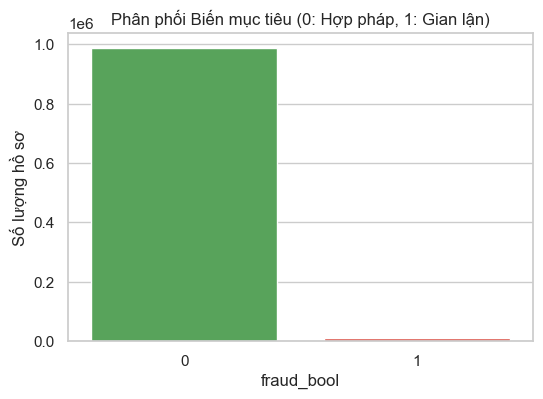

In [7]:
# Biểu đồ đếm số lượng hồ sơ theo biến mục tiêu
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_col, palette=['#4CAF50', '#F44336'])
plt.title("Phân phối Biến mục tiêu (0: Hợp pháp, 1: Gian lận)")
plt.xlabel("fraud_bool")
plt.ylabel("Số lượng hồ sơ")
plt.show()


**Nhận xét:** Tỷ lệ gian lận khoảng 1.10% (khoảng 1 hồ sơ gian lận trên 89 hồ sơ hợp pháp), tức là bài toán mất cân bằng rất mạnh. Hệ quả cho bước mô hình hóa:
- **Accuracy không dùng được.** Đoán toàn bộ hồ sơ là hợp pháp đã đạt khoảng 98.9% accuracy nhưng bỏ sót 100% gian lận.
- Nên dùng **PR-AUC**, **ROC-AUC** và **TPR tại FPR 5%** (TPR@5%FPR). Theo **[1]** (Section 3, *Performance Metric*): metric chính thức là *TPR tại FPR = 5%* — "this metric is typically imposed by clients in the fraud detection domain, since it strikes a balance between detecting fraud (TPR), and keeping customer attrition low".
- Cần xử lý mất cân bằng bằng trọng số lớp (`class_weight='balanced'`, `scale_pos_weight`), chỉnh ngưỡng quyết định hoặc lấy mẫu lại.


## 2. Dữ liệu khuyết

### 2.1 Missing bị che giấu

Khi gọi `df.isna()` thì kết quả là 0 trên cả 32 cột. Tuy nhiên datasheet ghi rằng giá trị thiếu được mã hóa bằng số âm (-1, riêng `intended_balcon_amount` là mọi giá trị âm). Vì vậy nhóm phải tự tìm các giá trị này.


> **Lưu ý từ [2] (Q9):** *"There is no missing information from individual instances"* — về mặt kỹ thuật không có NaN thật sự; các giá trị thiếu được **mã hóa cố ý** bằng số âm trong quá trình tạo dữ liệu. Điều này khác với missing ngẫu nhiên (MCAR) thường gặp.


In [8]:
# Kiểm tra giá trị NaN mặc định của Pandas
print("Số lượng giá trị NaN mặc định của Pandas:", df.isna().sum().sum())


Số lượng giá trị NaN mặc định của Pandas: 0


Đếm số giá trị bằng -1 ở từng cột:


In [9]:
# Đếm các cột chứa giá trị = -1
neg_counts = (df == -1).sum()
print("Top các cột chứa giá trị bằng -1:")
display(neg_counts[neg_counts > 0].sort_values(ascending=False))


Top các cột chứa giá trị bằng -1:


prev_address_months_count       712920
bank_months_count               253635
current_address_months_count      4254
session_length_in_minutes         2015
credit_risk_score                  488
device_distinct_emails_8w          359
dtype: int64

Cột `credit_risk_score` cũng có 488 dòng bằng -1, nhưng điểm này có khoảng giá trị [-191, 389] nên -1 ở đây là điểm hợp lệ và nhóm **không** coi là missing.

Riêng `intended_balcon_amount`, theo **[2] (Q7)**: *"negatives are missing values"* — mọi giá trị âm đều là missing, nên đếm theo điều kiện `< 0`:


In [10]:
# Kiểm tra giá trị âm ở cột intended_balcon_amount
balcon_neg = (df['intended_balcon_amount'] < 0).sum()
print(f"Số dòng thiếu ở intended_balcon_amount (< 0): {balcon_neg:,} dòng ({balcon_neg/len(df)*100:.2f}%)")


Số dòng thiếu ở intended_balcon_amount (< 0): 742,523 dòng (74.25%)


### 2.2 Cột hằng số `device_fraud_count`

Kiểm tra các giá trị của `device_fraud_count`. Nếu cột chỉ có một giá trị duy nhất thì không mang thông tin gì và có thể bỏ.


In [11]:
# Kiểm tra giá trị duy nhất trong device_fraud_count
print("Các giá trị duy nhất trong 'device_fraud_count':", df['device_fraud_count'].unique())

# Xóa cột device_fraud_count vì 100% dòng đều bằng 0 (cột hằng số, không có phương sai)
df = df.drop(columns=['device_fraud_count'], errors='ignore')
print("Đã xóa thành công cột 'device_fraud_count' khỏi bảng dữ liệu.")


Các giá trị duy nhất trong 'device_fraud_count': [0]
Đã xóa thành công cột 'device_fraud_count' khỏi bảng dữ liệu.


### 2.3 Chuẩn hóa missing sang NaN và tạo cờ

Theo **[2] (Q7)**, có **6 cột** được mã hóa missing bằng số âm:

| Cột | Quy tắc missing theo [2] |
|-----|---------------------------|
| `prev_address_months_count` | `-1 is a missing value` |
| `current_address_months_count` | `-1 is a missing value` |
| `bank_months_count` | `-1 is a missing value` |
| `session_length_in_minutes` | `-1 is a missing value` |
| `device_distinct_emails_8w` | `-1 is a missing value` |
| `intended_balcon_amount` | `negatives are missing values` (mọi giá trị âm) |

Với 6 cột này, nhóm làm hai việc:
1. Tạo cột cờ `<tên cột>_flag` (1 = thiếu, 0 = đủ) **trước** khi sửa dữ liệu.
2. Chuyển các giá trị `-1` (hoặc `< 0` với `intended_balcon_amount`) thành `np.nan`.


In [12]:
# Danh sách 6 cột chứa dữ liệu thiếu bị ẩn đã xác định từ docs
masked_cols = [
    'prev_address_months_count',
    'intended_balcon_amount',
    'bank_months_count',
    'current_address_months_count',
    'session_length_in_minutes',
    'device_distinct_emails_8w'
]

# Tạo cột cờ _flag và gán np.nan cho giá trị bị khuyết
for col in masked_cols:
    if col == 'intended_balcon_amount':
        df[f'{col}_flag'] = (df[col] < 0).astype(int)
        df.loc[df[col] < 0, col] = np.nan
    else:
        df[f'{col}_flag'] = (df[col] == -1).astype(int)
        df.loc[df[col] == -1, col] = np.nan

print("Đã tạo xong 6 cột cờ '_flag' và chuyển đổi các giá trị khuyết sang NaN!")


Đã tạo xong 6 cột cờ '_flag' và chuyển đổi các giá trị khuyết sang NaN!


Bảng tỷ lệ thiếu của 6 cột:


In [13]:
# Bảng thống kê tỷ lệ thiếu dữ liệu thực tế
missing_summary = pd.DataFrame({
    'Tên cột': masked_cols,
    'Số dòng thiếu': df[masked_cols].isna().sum().values,
    'Tỷ lệ thiếu (%)': (df[masked_cols].isna().mean() * 100).round(2).values
}).sort_values(by='Tỷ lệ thiếu (%)', ascending=False)

display(missing_summary)


,Tên cột,Số dòng thiếu,Tỷ lệ thiếu (%)
1,intended_balcon_amount,742523,74.25
0,prev_address_months_count,712920,71.29
2,bank_months_count,253635,25.36
3,current_address_months_count,4254,0.43
4,session_length_in_minutes,2015,0.20
5,device_distinct_emails_8w,359,0.04


Ý nghĩa của 6 cột này (theo **[2] Q7**; diễn giải nghiệp vụ là suy luận của nhóm vì dữ liệu tổng hợp):
1. `intended_balcon_amount` (thiếu ~74.25%): ứng viên không cung cấp số tiền dự kiến chuyển vào tài khoản mới.
2. `prev_address_months_count` (thiếu ~71.29%): không khai báo thời gian ở địa chỉ cũ (có thể ở một chỗ từ nhỏ, hoặc không khai).
3. `bank_months_count` (thiếu ~25.36%): có thể là chưa có tài khoản ngân hàng trước đây.
4. `current_address_months_count` (thiếu ~0.43%): thiếu số tháng ở địa chỉ hiện tại.
5. `session_length_in_minutes` (thiếu ~0.20%): có thể do hệ thống không ghi nhận được thời lượng phiên.
6. `device_distinct_emails_8w` (thiếu ~0.04%): không xác định được số email liên kết với thiết bị.


### 2.4 Thiếu dữ liệu có liên quan đến gian lận không?

Câu hỏi: khách không điền thông tin có liên quan đến gian lận hay không? Nhóm so sánh tỷ lệ gian lận giữa hồ sơ đủ (`flag = 0`) và hồ sơ thiếu (`flag = 1`) của từng cột.


In [14]:
# So sánh tỷ lệ gian lận giữa hồ sơ Đầy đủ (flag=0) và hồ sơ Thiếu (flag=1)
signals = []
for col in masked_cols:
    rate_valid = df.loc[df[f'{col}_flag'] == 0, target_col].mean() * 100
    rate_missing = df.loc[df[f'{col}_flag'] == 1, target_col].mean() * 100
    ratio = rate_missing / rate_valid if rate_valid > 0 else 0
    signals.append({
        'Thuộc tính': col,
        'Tỷ lệ gian lận khi Đủ (%)': round(rate_valid, 2),
        'Tỷ lệ gian lận khi Thiếu (%)': round(rate_missing, 2),
        'Rủi ro tăng gấp (lần)': round(ratio, 2)
    })

df_signal = pd.DataFrame(signals).sort_values(by='Rủi ro tăng gấp (lần)', ascending=False)
display(df_signal)


,Thuộc tính,Tỷ lệ gian lận khi Đủ (%),Tỷ lệ gian lận khi Thiếu (%),Rủi ro tăng gấp (lần)
0,prev_address_months_count,0.31,1.42,4.56
1,intended_balcon_amount,0.50,1.31,2.64
2,bank_months_count,0.92,1.63,1.77
5,device_distinct_emails_8w,1.10,1.11,1.01
4,session_length_in_minutes,1.10,0.89,0.81
3,current_address_months_count,1.11,0.33,0.30


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28924\726855386.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_signal, y='Thuộc tính', x='Rủi ro tăng gấp (lần)', palette='Reds_r')


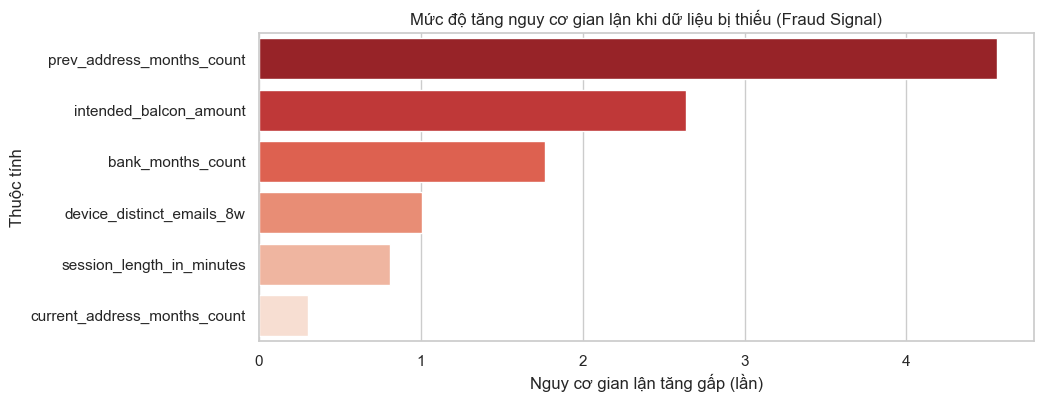

In [15]:
# Biểu đồ mức độ tăng nguy cơ gian lận
plt.figure(figsize=(10, 4))
sns.barplot(data=df_signal, y='Thuộc tính', x='Rủi ro tăng gấp (lần)', hue='Thuộc tính', palette='Reds_r', legend=False)
plt.title("Mức độ tăng nguy cơ gian lận khi dữ liệu bị thiếu (Fraud Signal)")
plt.xlabel("Nguy cơ gian lận tăng gấp (lần)")
plt.ylabel("Thuộc tính")
plt.show()


**Nhận xét:**
1. Thiếu `prev_address_months_count`: tỷ lệ gian lận **1.42%**, so với **0.31%** ở nhóm khai đủ (cao gấp 4.56 lần).
2. Thiếu `intended_balcon_amount`: **1.31%** so với **0.50%** (gấp 2.64 lần).
3. Thiếu `bank_months_count`: **1.63%** so với **0.92%** (gấp 1.77 lần).
4. Ba cột còn lại **không** cho tín hiệu cùng chiều: thiếu `current_address_months_count` có tỷ lệ gian lận chỉ 0.33% (thấp hơn nhóm đủ là 1.11%), `session_length_in_minutes` thiếu là 0.89% so với 1.10%, còn `device_distinct_emails_8w` thiếu gần như không khác (1.11% so với 1.10%). Vì vậy không thể nói "cột nào thiếu cũng là dấu hiệu rủi ro".

**Kết luận:** với 3 cột đầu, việc thiếu dữ liệu có liên hệ với nhãn (informative missingness; khái niệm này khác với MNAR vốn không kiểm chứng được từ dữ liệu quan sát). Vì vậy không nên xóa các dòng thiếu dữ liệu và nên giữ các cột cờ `_flag` làm đặc trưng. Với 3 cột còn lại, cần xem mô hình có dùng cờ hay không trước khi quyết định giữ.


### 2.5 Có nên điền giá trị thiếu bằng median?

Nhóm thử trên `bank_months_count` (thiếu khoảng 25%): điền median rồi so sánh histogram trước và sau khi điền.


In [16]:
# Thử nghiệm điền Median trên cột bank_months_count
test_col = 'bank_months_count'
before_values = df[test_col].dropna()

# Lấy giá trị trung vị
median_val = df[test_col].median()
after_values = df[test_col].fillna(median_val)

print(f"Giá trị trung vị (Median) của {test_col}: {median_val}")


Giá trị trung vị (Median) của bank_months_count: 15.0


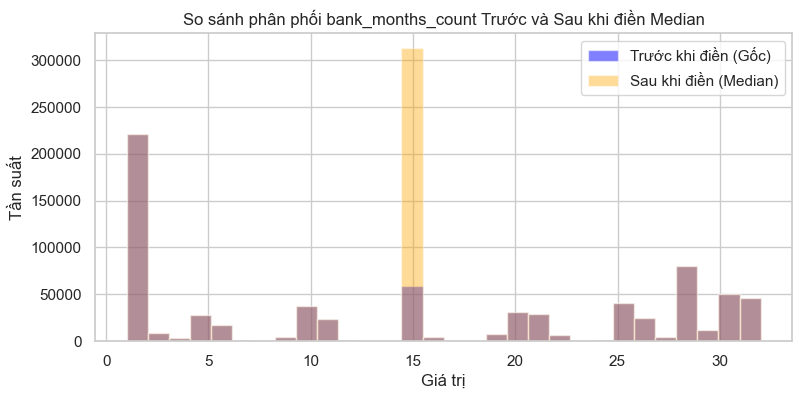

In [17]:
# Biểu đồ so sánh phân phối Trước vs Sau khi điền Median
plt.figure(figsize=(9, 4))
plt.hist(before_values, bins=30, alpha=0.5, label='Trước khi điền (Gốc)', color='blue')
plt.hist(after_values, bins=30, alpha=0.4, label='Sau khi điền (Median)', color='orange')
plt.title(f"So sánh phân phối {test_col} Trước và Sau khi điền Median")
plt.xlabel("Giá trị")
plt.ylabel("Tần suất")
plt.legend()
plt.show()


**Nhận xét:** Khi điền một giá trị cố định (median = 15) thì xuất hiện một cột rất cao tại đúng giá trị đó, làm méo phân phối gốc. Với các mô hình cây như LightGBM, XGBoost, CatBoost thì không cần điền, vì các mô hình này tự xử lý NaN. Nhóm sẽ giữ NaN kết hợp với các cột cờ `_flag`. Nếu dùng mô hình tuyến tính thì mới cần điền, và phải tính median trên Train.


> **Lưu ý từ [1] (Section 5):** Tác giả không chỉ định chiến lược imputation cụ thể. Với mô hình cây (LightGBM, XGBoost, CatBoost), NaN được xử lý tự động — không cần điền. Chỉ cần điền khi dùng mô hình tuyến tính, và phải tính thống kê (median) trên **Train** để tránh data leakage.


## 3. Chia dữ liệu theo thời gian

### 3.1 Cách chia

Cột `month` (0–7) cho biết hồ sơ nộp vào tháng nào. Vì phân phối thay đổi theo thời gian (xem 3.2), nhóm chia theo tháng thay vì chia ngẫu nhiên, để mô phỏng việc huấn luyện trên quá khứ và dự đoán tương lai:

- **Train:** tháng 0–5
- **Validation:** tháng 6 (chọn đặc trưng, chỉnh ngưỡng)
- **Test (out-of-time):** tháng 7, chỉ dùng một lần ở bước cuối

Theo **[1]** (Section 3, *Splitting Strategy*): *"Leveraging the 'month' column, we were able to split the data temporally: the first six months for training, the last two for testing. This is common practice in the fraud domain."* **[2] (Q11)** xác nhận đây cũng là split dùng trong paper: *"The results presented in the paper use the first six months of data for training and the last two months for validation."* Nhóm sử dụng tháng 6 làm Val và tháng 7 làm Test (out-of-time).

**Phạm vi dùng dữ liệu trong notebook:**
- Các phần EDA mô tả (phần 4 và 5) chạy trên toàn bộ 1 triệu dòng để các nhóm nhỏ có đủ mẫu. Kết quả này chỉ dùng để hiểu dữ liệu.
- Các bước học thông tin từ nhãn hoặc từ dữ liệu (ngưỡng của `syndicate_score`, IV, scaler, imputer, PCA, mô hình baseline) chỉ fit trên **Train**.


In [18]:
# 1. Phân chia 3 tập dữ liệu chuẩn hóa theo trục thời gian (Temporal Split)
df_train = df[df['month'] <= 5].copy()
df_val = df[df['month'] == 6].copy()
df_test = df[df['month'] == 7].copy()

# Bảng tóm tắt cấu trúc phân chia dữ liệu
split_summary = pd.DataFrame([
    {'Tập Dữ Liệu': 'Train (Huấn luyện)', 'Khoảng Tháng': 'Tháng 0 – 5', 'Số Bản Ghi': len(df_train), 
     'Tỷ Lệ (%)': len(df_train)/len(df)*100, 'Số Gian Lận': df_train[target_col].sum(), 'Tỷ Lệ Gian Lận (%)': df_train[target_col].mean()*100},
    {'Tập Dữ Liệu': 'Validation (Thẩm định)', 'Khoảng Tháng': 'Tháng 6', 'Số Bản Ghi': len(df_val), 
     'Tỷ Lệ (%)': len(df_val)/len(df)*100, 'Số Gian Lận': df_val[target_col].sum(), 'Tỷ Lệ Gian Lận (%)': df_val[target_col].mean()*100},
    {'Tập Dữ Liệu': 'Test OOT (Kiểm thử)', 'Khoảng Tháng': 'Tháng 7', 'Số Bản Ghi': len(df_test), 
     'Tỷ Lệ (%)': len(df_test)/len(df)*100, 'Số Gian Lận': df_test[target_col].sum(), 'Tỷ Lệ Gian Lận (%)': df_test[target_col].mean()*100}
])
display(split_summary.round(2))

,Tập Dữ Liệu,Khoảng Tháng,Số Bản Ghi,Tỷ Lệ (%),Số Gian Lận,Tỷ Lệ Gian Lận (%)
0,Train (Huấn luyện),Tháng 0 – 5,794989,79.50,8151,1.03
1,Validation (Thẩm định),Tháng 6,108168,10.82,1450,1.34
2,Test OOT (Kiểm thử),Tháng 7,96843,9.68,1428,1.47


### 3.2 Tỷ lệ gian lận theo tháng

Vẽ tỷ lệ gian lận trung bình theo từng tháng:


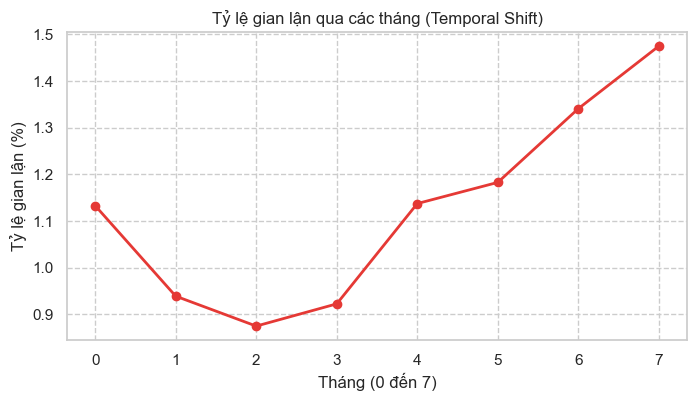

,N,Fraud_N,Rate
month,,,
0,132440,1500,1.133
1,127620,1198,0.939
2,136979,1198,0.875
3,150936,1392,0.922
4,127691,1452,1.137
5,119323,1411,1.183
6,108168,1450,1.341
7,96843,1428,1.475


In [19]:
# Tỷ lệ gian lận trung bình theo từng tháng
monthly_trend = df.groupby('month')[target_col].mean() * 100

plt.figure(figsize=(8, 4))
monthly_trend.plot(marker='o', color='#E53935', linewidth=2)
plt.title("Tỷ lệ gian lận qua các tháng (Temporal Shift)")
plt.xlabel("Tháng (0 đến 7)")
plt.ylabel("Tỷ lệ gian lận (%)")
plt.grid(True, linestyle='--')
plt.show()
display(df.groupby('month')[target_col].agg(N='count', Fraud_N='sum', Rate='mean').assign(Rate=lambda d: d['Rate']*100).round(3))

**Nhận xét:** tỷ lệ gian lận tăng dần theo thời gian: Train (tháng 0–5) khoảng 1.03%, Val (tháng 6) khoảng 1.34%, Test (tháng 7) khoảng 1.47%. Theo **[1]** (Section 3.1): *"The prevalence of fraud varies between 0.85% and 1.5% of the instances over different months. We observe that these values are higher for the later months."* Có hai hệ quả:
- Baseline của PR-AUC khác nhau giữa các tập, nên khi so sánh PR-AUC cần chia cho tỷ lệ gian lận của từng tập.
- Ngưỡng quyết định học trên Train có thể bị lệch khi áp dụng cho tháng sau, nên cần kiểm tra lại độ hiệu chuẩn (calibration) của xác suất.


## 4. Khám phá từng nhóm biến

Phần này xem từng nhóm biến liên quan thế nào đến gian lận. Đường nét đứt trong các biểu đồ là tỷ lệ gian lận trung bình (~1.10%). Với các nhóm nhỏ, nhóm có kèm cỡ mẫu N và khoảng tin cậy Wilson 95% để tránh kết luận từ vài hồ sơ.

### 4.1 Biến phân loại: hệ điều hành, phương thức thanh toán, nhà ở

Trước hết xem phân phối của `device_os`, `payment_type` và `housing_status`.


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28924\779495286.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='device_os', order=df['device_os'].value_counts().index, palette='Blues_r')


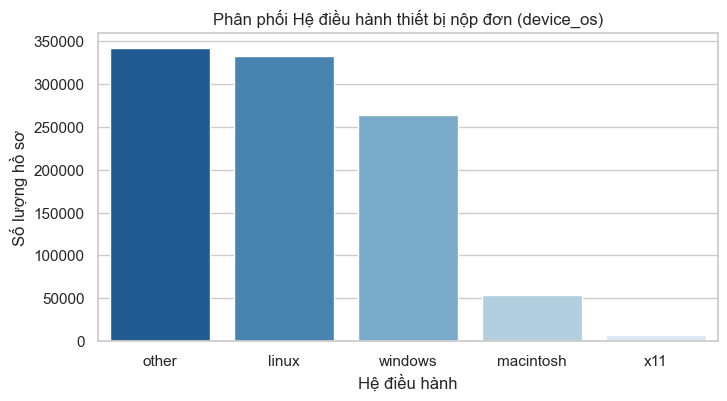

In [20]:
# Biểu đồ phân phối hệ điều hành thiết bị nộp đơn (device_os)
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='device_os', order=df['device_os'].value_counts().index, palette='Blues_r')
plt.title("Phân phối Hệ điều hành thiết bị nộp đơn (device_os)")
plt.xlabel("Hệ điều hành")
plt.ylabel("Số lượng hồ sơ")
plt.show()


Phân phối `payment_type` và `housing_status`:


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28924\1326590732.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='payment_type', order=df['payment_type'].value_counts().index, ax=axes[0], palette='Set2')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28924\1326590732.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='housing_status', order=df['housing_status'].value_counts().index, ax=axes[1], palette='Set2')


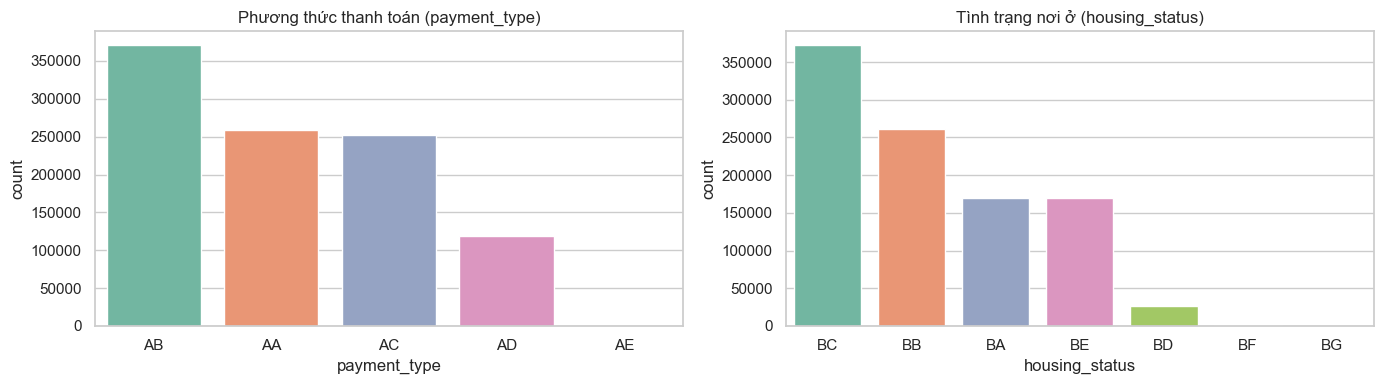

In [21]:
# Biểu đồ phương thức thanh toán và tình trạng nơi ở
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(data=df, x='payment_type', order=df['payment_type'].value_counts().index, ax=axes[0], palette='Set2')
axes[0].set_title("Phương thức thanh toán (payment_type)")

sns.countplot(data=df, x='housing_status', order=df['housing_status'].value_counts().index, ax=axes[1], palette='Set2')
axes[1].set_title("Tình trạng nơi ở (housing_status)")

plt.tight_layout()
plt.show()


**Quan sát:**
- Phần lớn hồ sơ nộp từ thiết bị chạy Windows, tiếp theo là other, macOS và Linux.
- Về phương thức thanh toán, nhóm `AB` và `AC` chiếm đa số.
- Về nhà ở, nhóm `BC` và `BE` có nhiều hồ sơ nhất.


Tiếp theo xem tỷ lệ gian lận theo `device_os` và `payment_type`:


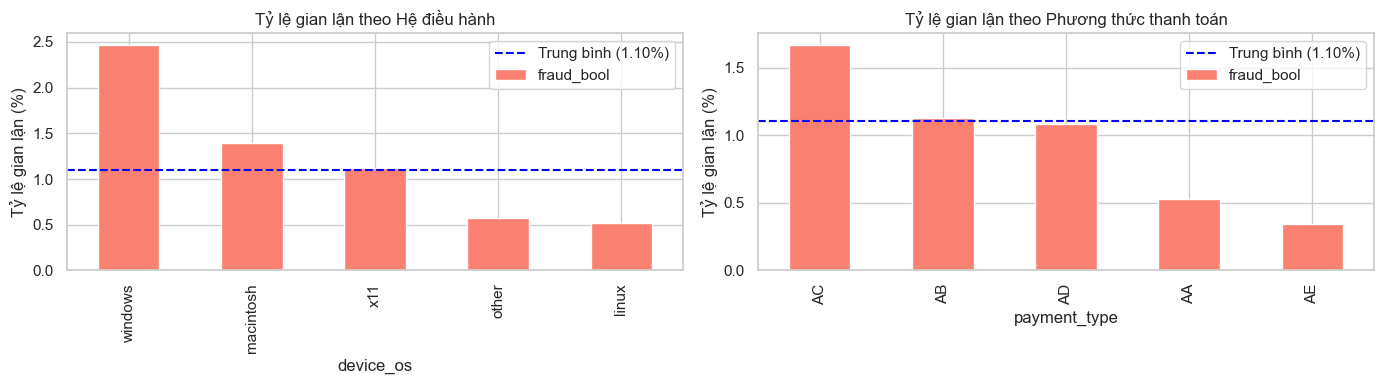

In [22]:
# Biểu đồ tỷ lệ gian lận theo hệ điều hành và phương thức thanh toán
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 1. Tỷ lệ gian lận theo hệ điều hành (device_os)
os_risk = (df.groupby('device_os')[target_col].mean() * 100).sort_values(ascending=False)
os_risk.plot(kind='bar', ax=axes[0], color='salmon')
axes[0].axhline(baseline_fraud, color='blue', linestyle='--', label=f'Trung bình ({baseline_fraud:.2f}%)')
axes[0].set_title("Tỷ lệ gian lận theo Hệ điều hành")
axes[0].set_ylabel("Tỷ lệ gian lận (%)")
axes[0].legend()

# 2. Tỷ lệ gian lận theo phương thức thanh toán (payment_type)
pay_risk = (df.groupby('payment_type')[target_col].mean() * 100).sort_values(ascending=False)
pay_risk.plot(kind='bar', ax=axes[1], color='salmon')
axes[1].axhline(baseline_fraud, color='blue', linestyle='--', label=f'Trung bình ({baseline_fraud:.2f}%)')
axes[1].set_title("Tỷ lệ gian lận theo Phương thức thanh toán")
axes[1].set_ylabel("Tỷ lệ gian lận (%)")
axes[1].legend()

plt.tight_layout()
plt.show()


**Nhận xét:**
- Hệ điều hành Linux và other có tỷ lệ gian lận cao hơn mức trung bình (trên 1.6% so với 1.10%).
- Phương thức thanh toán `AB` và `AC` có tỷ lệ gian lận cao hơn các nhóm còn lại.


### 4.2 Cờ xác thực, nghề nghiệp và hành vi phiên

Câu hỏi: các cờ như `foreign_request` (đơn từ nước khác), `email_is_free` (email miễn phí), `phone_home_valid` (điện thoại bàn hợp lệ) có liên quan đến gian lận không?


In [23]:
# Tính tỷ lệ gian lận theo 3 cờ kiểm tra danh tính và địa lý
id_signals = pd.DataFrame({
    'foreign_request': df.groupby('foreign_request')[target_col].mean() * 100,
    'email_is_free': df.groupby('email_is_free')[target_col].mean() * 100,
    'phone_home_valid': df.groupby('phone_home_valid')[target_col].mean() * 100
})

display(id_signals.round(2))


,foreign_request,email_is_free,phone_home_valid
0,1.07,0.80,1.41
1,2.20,1.38,0.67


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28924\1718221380.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['foreign_request'], y=df[target_col]*100, ax=axes[0], palette=['#81C784', '#E57373'])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28924\1718221380.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Nội địa (0)', 'Nước ngoài (1)'])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28924\1718221380.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['email_is_free'], y=df[target_col]*100, ax=axes[1], palette=['#81C784', '#E57373'])
C:\Users\Lenovo\AppData\Local\Te

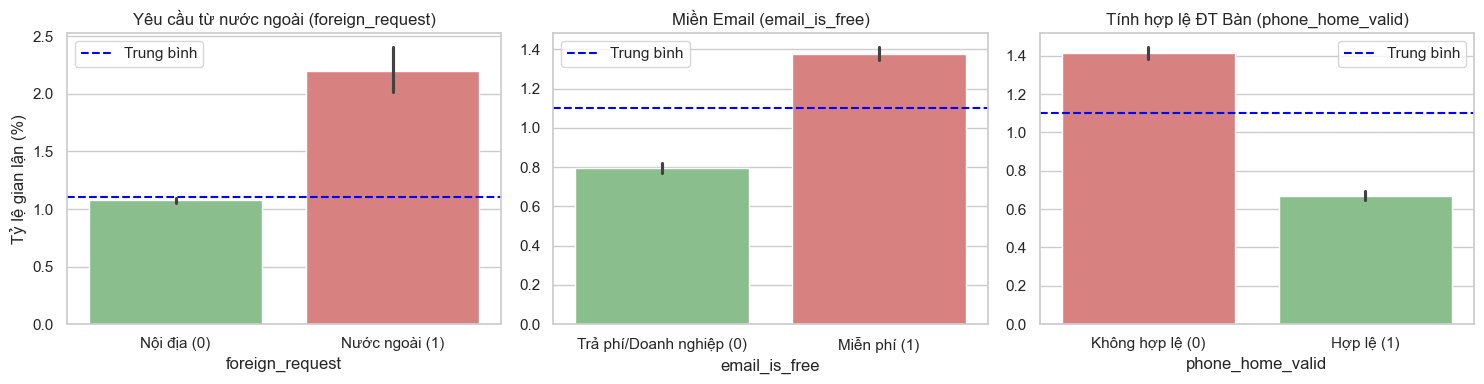

In [24]:
# Biểu đồ so sánh 3 cờ xác thực danh tính
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Yêu cầu từ nước ngoài
sns.barplot(x=df['foreign_request'], y=df[target_col]*100, ax=axes[0], palette=['#81C784', '#E57373'])
axes[0].axhline(baseline_fraud, color='blue', linestyle='--', label='Trung bình')
axes[0].set_title("Yêu cầu từ nước ngoài (foreign_request)")
axes[0].set_xticklabels(['Nội địa (0)', 'Nước ngoài (1)'])
axes[0].set_ylabel("Tỷ lệ gian lận (%)")
axes[0].legend()

# 2. Email miễn phí
sns.barplot(x=df['email_is_free'], y=df[target_col]*100, ax=axes[1], palette=['#81C784', '#E57373'])
axes[1].axhline(baseline_fraud, color='blue', linestyle='--', label='Trung bình')
axes[1].set_title("Miền Email (email_is_free)")
axes[1].set_xticklabels(['Trả phí/Doanh nghiệp (0)', 'Miễn phí (1)'])
axes[1].set_ylabel("")
axes[1].legend()

# 3. Điện thoại bàn hợp lệ
sns.barplot(x=df['phone_home_valid'], y=df[target_col]*100, ax=axes[2], palette=['#E57373', '#81C784'])
axes[2].axhline(baseline_fraud, color='blue', linestyle='--', label='Trung bình')
axes[2].set_title("Tính hợp lệ ĐT Bàn (phone_home_valid)")
axes[2].set_xticklabels(['Không hợp lệ (0)', 'Hợp lệ (1)'])
axes[2].set_ylabel("")
axes[2].legend()

plt.tight_layout()
plt.show()


**Nhận xét:**
- Đơn từ nước ngoài (`foreign_request = 1`): **2.20%**, gấp hơn 2 lần đơn nội địa (1.07%).
- Email miễn phí: **1.38%**, so với **0.80%** ở email trả phí/doanh nghiệp (gấp 1.73 lần).
- Điện thoại bàn không hợp lệ (`phone_home_valid = 0`): **1.41%**, so với **0.67%** khi hợp lệ.


Tiếp theo xem nghề nghiệp (`employment_status`) và tùy chọn duy trì phiên (`keep_alive_session`):


In [25]:
# Thống kê tỷ lệ gian lận theo từng nhóm nghề nghiệp
emp_risk = df.groupby('employment_status').agg(
    So_luong=(target_col, 'count'),
    Ty_le_gian_lan_pct=(target_col, lambda x: x.mean() * 100)
).sort_values(by='Ty_le_gian_lan_pct', ascending=False)

display(emp_risk.round(2))

# Thống kê tỷ lệ gian lận theo cờ keep_alive_session
keep_risk = df.groupby('keep_alive_session')[target_col].mean() * 100
print()
print("Tỷ lệ gian lận theo keep_alive_session:")
display(keep_risk.round(2))


,So_luong,Ty_le_gian_lan_pct
employment_status,,
CC,37758,2.47
CG,453,1.55
CA,730252,1.22
CB,138288,0.69
CD,26522,0.38
CE,22693,0.23
CF,44034,0.19



Tỷ lệ gian lận theo keep_alive_session:


keep_alive_session
0    1.72
1    0.65
Name: fraud_bool, dtype: float64

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28924\1269041762.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emp_risk.index, y=emp_risk['Ty_le_gian_lan_pct'], ax=axes[0], palette='magma')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28924\1269041762.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[0, 1], y=keep_risk.values, ax=axes[1], palette=['#E57373', '#81C784'])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28924\1269041762.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Không duy trì (0)', 'Có duy trì (1)'])


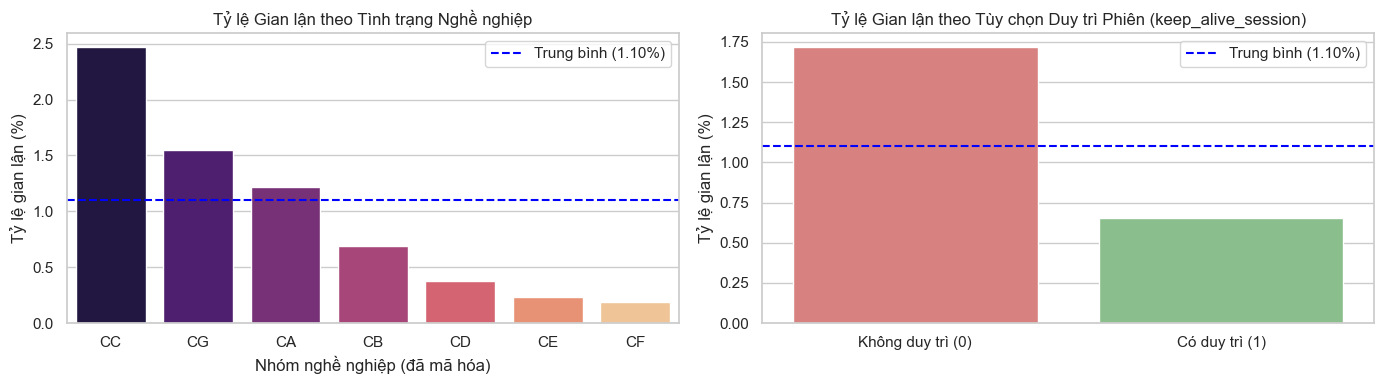

In [26]:
# Biểu đồ nghề nghiệp và hành vi phiên
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 1. Nghề nghiệp
sns.barplot(x=emp_risk.index, y=emp_risk['Ty_le_gian_lan_pct'], hue=emp_risk.index, ax=axes[0], palette='magma', legend=False)
axes[0].axhline(baseline_fraud, color='blue', linestyle='--', label=f'Trung bình ({baseline_fraud:.2f}%)')
axes[0].set_title("Tỷ lệ Gian lận theo Tình trạng Nghề nghiệp")
axes[0].set_xlabel("Nhóm nghề nghiệp (đã mã hóa)")
axes[0].set_ylabel("Tỷ lệ gian lận (%)")
axes[0].legend()

# 2. Duy trì phiên
sns.barplot(x=[0, 1], y=keep_risk.values, hue=[0, 1], ax=axes[1], palette=['#E57373', '#81C784'], legend=False)
axes[1].axhline(baseline_fraud, color='blue', linestyle='--', label=f'Trung bình ({baseline_fraud:.2f}%)')
axes[1].set_title("Tỷ lệ Gian lận theo Tùy chọn Duy trì Phiên (keep_alive_session)")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Không duy trì (0)', 'Có duy trì (1)'])
axes[1].set_ylabel("Tỷ lệ gian lận (%)")
axes[1].legend()

plt.tight_layout()
plt.show()


**Nhận xét:**
- Nghề nghiệp có chênh lệch rất lớn: nhóm `CC` cao nhất (**2.47%**, gấp 2.25 lần mức trung bình), nhóm `CF` thấp nhất (**0.19%**), tức là `CC` cao hơn `CF` khoảng 13 lần.
- Người **không** chọn duy trì phiên (`keep_alive_session = 0`) có tỷ lệ gian lận **1.72%**, gấp 2.65 lần nhóm có duy trì phiên (0.65%). Một giả thuyết là người gian lận thao tác nhanh rồi thoát, nhưng đây chỉ là suy đoán.


### 4.3 Biến số: thu nhập, điểm tín dụng, độ giống tên - email

Vì dữ liệu có 1 triệu dòng, nhóm lấy mẫu ngẫu nhiên 50.000 dòng để vẽ biểu đồ cho nhanh.


In [27]:
# Lấy mẫu ngẫu nhiên 50,000 dòng đại diện
df_sample = df.sample(50000, random_state=42).copy()
print("Kích thước tập mẫu dùng để trực quan hóa:", df_sample.shape)


Kích thước tập mẫu dùng để trực quan hóa: (50000, 37)


Boxplot của `income` và `credit_risk_score` theo nhóm gian lận:


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28924\4049453951.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sample, x=target_col, y='income', ax=axes[0], palette=['#4CAF50', '#F44336'])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28924\4049453951.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Hợp pháp (0)', 'Gian lận (1)'])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28924\4049453951.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sample, x=target_col, y='credit_risk_score', ax=axes[1], palette=['#4CAF50', '#F44336'])
C:\Users\Lenovo\AppData\Local\T

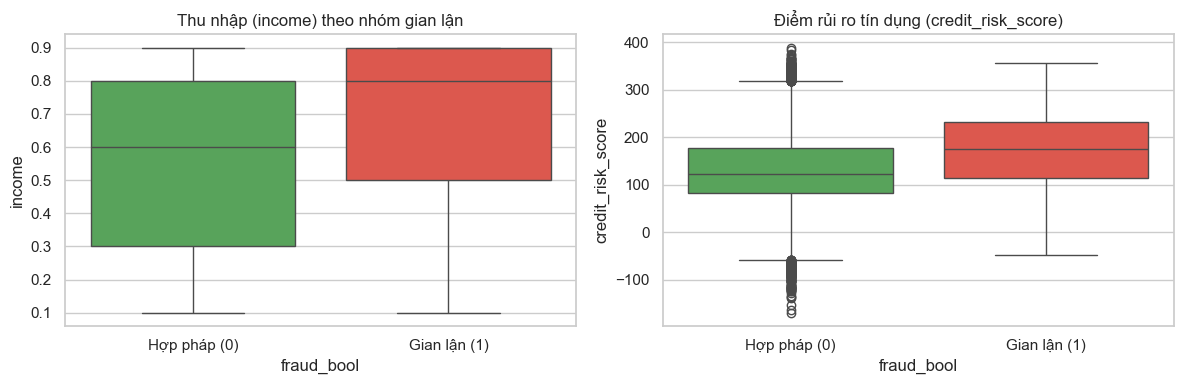

In [28]:
# So sánh phân phối thu nhập và điểm tín dụng
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df_sample, x=target_col, y='income', ax=axes[0], palette=['#4CAF50', '#F44336'])
axes[0].set_title("Thu nhập (income) theo nhóm gian lận")
axes[0].set_xticklabels(['Hợp pháp (0)', 'Gian lận (1)'])

sns.boxplot(data=df_sample, x=target_col, y='credit_risk_score', ax=axes[1], palette=['#4CAF50', '#F44336'])
axes[1].set_title("Điểm rủi ro tín dụng (credit_risk_score)")
axes[1].set_xticklabels(['Hợp pháp (0)', 'Gian lận (1)'])

plt.tight_layout()
plt.show()


Phân phối KDE của `name_email_similarity` giữa hai nhóm:


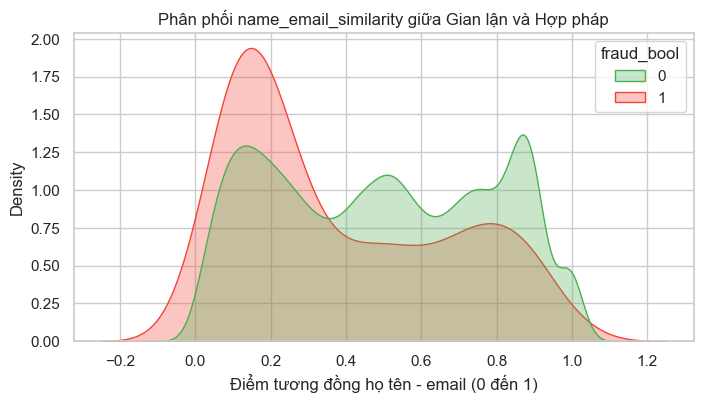

In [29]:
# Biểu đồ mật độ KDE của name_email_similarity
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df_sample, x='name_email_similarity', hue=target_col,
            common_norm=False, palette=['#4CAF50', '#F44336'], fill=True, alpha=0.3)
plt.title("Phân phối name_email_similarity giữa Gian lận và Hợp pháp")
plt.xlabel("Điểm tương đồng họ tên - email (0 đến 1)")
plt.show()


**Quan sát:**
- Nhóm gian lận có `name_email_similarity` thấp hơn rõ so với nhóm hợp pháp. Có thể do dùng email không liên quan đến tên, nhưng đây chỉ là giả thuyết.
- `credit_risk_score` của nhóm gian lận dịch về phía cao hơn.


### 4.4 Biến vận tốc và giá trị ngoại lai

**Câu hỏi:** các giá trị rất lớn của `velocity_6h` có phải là dấu hiệu tấn công tự động (botnet) không? Nhóm xác định ngoại lai bằng quy tắc IQR: ngưỡng trên = Q3 + 1.5 × IQR, sau đó so sánh tỷ lệ gian lận của nhóm ngoại lai và nhóm bình thường.


In [30]:
# Xác định ngưỡng ngoại lai IQR cho velocity_6h
q1 = df['velocity_6h'].quantile(0.25)
q3 = df['velocity_6h'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

# Phân chia thành nhóm Bình thường và nhóm Ngoại lai (Outlier)
outlier_mask = df['velocity_6h'] > upper_bound
fraud_normal = df.loc[~outlier_mask, target_col].mean() * 100
fraud_outlier = df.loc[outlier_mask, target_col].mean() * 100

print(f"Ngưỡng ngoại lai trên (Upper Bound): {upper_bound:.1f} đơn/giờ")
print(f"Số lượng hồ sơ ngoại lai: {outlier_mask.sum():,} ({outlier_mask.mean()*100:.2f}%)")
print(f"Tỷ lệ gian lận nhóm Bình thường : {fraud_normal:.2f}%")
print(f"Tỷ lệ gian lận nhóm Ngoại lai   : {fraud_outlier:.2f}%")


Ngưỡng ngoại lai trên (Upper Bound): 14047.2 đơn/giờ
Số lượng hồ sơ ngoại lai: 9,005 (0.90%)
Tỷ lệ gian lận nhóm Bình thường : 1.11%
Tỷ lệ gian lận nhóm Ngoại lai   : 0.69%


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28924\3561963912.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sample, x=target_col, y='velocity_6h', ax=axes[1], palette=['#4CAF50', '#F44336'])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28924\3561963912.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Hợp pháp (0)', 'Gian lận (1)'])


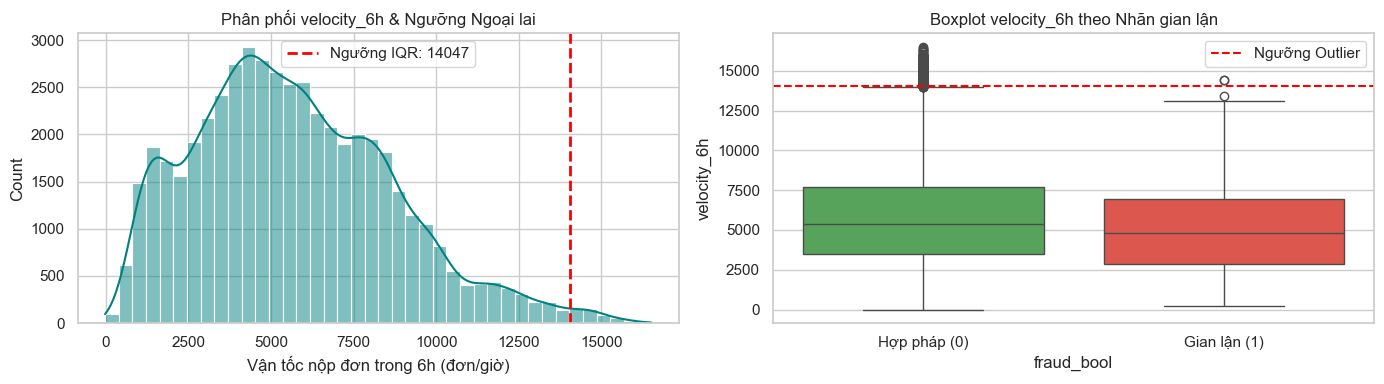

In [31]:
# Trực quan hóa phân tích ngoại lai velocity_6h
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 1. Histogram và đường ngưỡng IQR
sns.histplot(df_sample['velocity_6h'], bins=40, kde=True, ax=axes[0], color='teal')
axes[0].axvline(upper_bound, color='red', linestyle='--', linewidth=2, label=f'Ngưỡng IQR: {upper_bound:.0f}')
axes[0].set_title("Phân phối velocity_6h & Ngưỡng Ngoại lai")
axes[0].set_xlabel("Vận tốc nộp đơn trong 6h (đơn/giờ)")
axes[0].legend()

# 2. Boxplot so sánh theo nhãn gian lận
sns.boxplot(data=df_sample, x=target_col, y='velocity_6h', ax=axes[1], palette=['#4CAF50', '#F44336'])
axes[1].axhline(upper_bound, color='red', linestyle='--', linewidth=1.5, label='Ngưỡng Outlier')
axes[1].set_title("Boxplot velocity_6h theo Nhãn gian lận")
axes[1].set_xticklabels(['Hợp pháp (0)', 'Gian lận (1)'])
axes[1].legend()

plt.tight_layout()
plt.show()


**Nhận xét:**
- Ngưỡng trên của `velocity_6h` khoảng 14,047; có 9,005 hồ sơ (0.90%) vượt ngưỡng này.
- Tỷ lệ gian lận ở nhóm ngoại lai (0.69%) lại **thấp hơn** nhóm bình thường (1.11%). Kết quả này không ủng hộ giả định "velocity cao thì là botnet". Một giả thuyết khả dĩ là lượng hồ sơ hợp pháp tăng đồng loạt (ví dụ do chiến dịch của ngân hàng), nhưng dữ liệu không có thông tin để xác nhận.
- Nhóm **không xóa** các điểm ngoại lai này. Với mô hình tuyến tính có thể dùng `RobustScaler`; với mô hình cây thì không cần scaling. Scaling cũng không giải quyết được vấn đề trôi dạt phân phối (xem phần 7).


Tiếp theo xem tương quan giữa ba khung vận tốc (`velocity_6h`, `velocity_24h`, `velocity_4w`) và mật độ hồ sơ theo mã bưu chính (`zip_count_4w`):


In [32]:
# So sánh phân phối tương quan giữa 3 khung thời gian vận tốc
vel_cols = ['velocity_6h', 'velocity_24h', 'velocity_4w']
vel_corr = df[vel_cols].corr()

# Khảo sát biến zip_count_4w theo phân vị
df['zip_bins'] = pd.qcut(df['zip_count_4w'], q=5)
zip_risk = df.groupby('zip_bins', observed=False)[target_col].agg(
    Tong_Don='count',
    Ty_Le_Gian_Lan='mean'
).reset_index()
zip_risk['Ty_Le_Gian_Lan (%)'] = zip_risk['Ty_Le_Gian_Lan'] * 100

print("Ma trận tương quan giữa các khung vận tốc:")
print(vel_corr)


Ma trận tương quan giữa các khung vận tốc:
              velocity_6h  velocity_24h  velocity_4w
velocity_6h      1.000000      0.464003     0.400254
velocity_24h     0.464003      1.000000     0.539115
velocity_4w      0.400254      0.539115     1.000000


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28924\2807811304.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=zip_risk, x='zip_bins', y='Ty_Le_Gian_Lan (%)', palette='Purples', ax=axes[1])


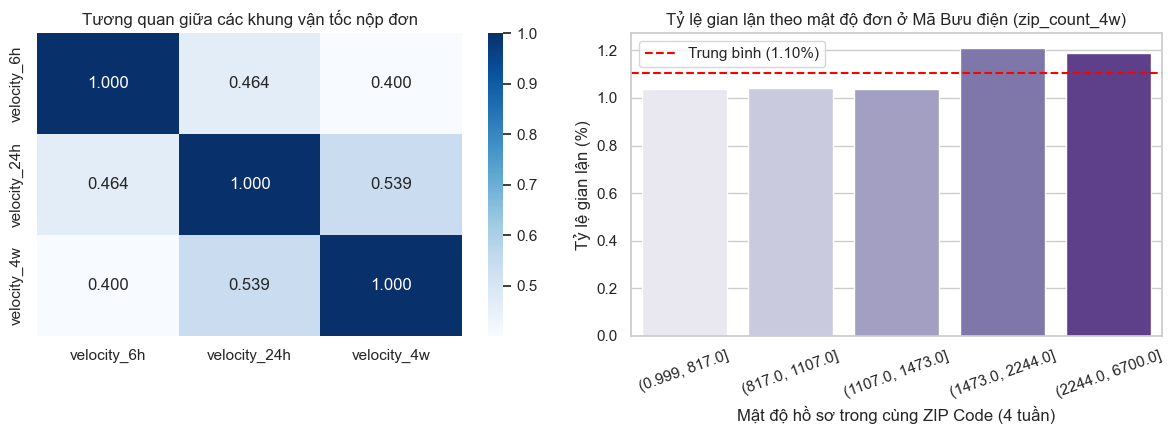

In [33]:
# Trực quan hóa ma trận tương quan vận tốc và rủi ro theo mật độ bưu chính
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.heatmap(vel_corr, annot=True, cmap='Blues', fmt='.3f', ax=axes[0])
axes[0].set_title("Tương quan giữa các khung vận tốc nộp đơn")

sns.barplot(data=zip_risk, x='zip_bins', y='Ty_Le_Gian_Lan (%)', hue='zip_bins', palette='Purples', ax=axes[1], legend=False)
axes[1].axhline(df[target_col].mean()*100, color='red', linestyle='--', label='Trung bình (1.10%)')
axes[1].set_title("Tỷ lệ gian lận theo mật độ đơn ở Mã Bưu điện (zip_count_4w)")
axes[1].set_xlabel("Mật độ hồ sơ trong cùng ZIP Code (4 tuần)")
axes[1].set_ylabel("Tỷ lệ gian lận (%)")
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend()

plt.tight_layout()
plt.show()


**Nhận xét:**
- Các biến vận tốc có tương quan ở mức vừa: `velocity_6h` - `velocity_24h` khoảng 0.46, `velocity_24h` - `velocity_4w` khoảng 0.54, `velocity_6h` - `velocity_4w` khoảng 0.40. Chưa đủ để kết luận đa cộng tuyến (nên kiểm tra VIF nếu dùng mô hình tuyến tính). Biến tỷ lệ giữa các khung giờ (xem 6.1) vẫn đáng thử.
- Ở những khu vực có nhiều hồ sơ trong 4 tuần (`zip_count_4w` > 1,473), tỷ lệ gian lận trên 1.21%, so với 1.03% ở khu vực thưa.


### 4.5 Thiết bị dùng chung và ngày sinh trùng email

Hai biến thể hiện khả năng một người (hoặc nhóm) nộp nhiều hồ sơ: `device_distinct_emails_8w` (số email khác nhau trên cùng thiết bị trong 8 tuần) và `date_of_birth_distinct_emails_4w` (số email khác nhau dùng chung một ngày sinh trong 4 tuần). Cột `device_fraud_count` đã bị bỏ ở 2.2.


In [34]:
# 1. Thống kê tỷ lệ gian lận theo số email xuất hiện trên thiết bị trong 8 tuần (device_distinct_emails_8w)
device_email_stats = df.groupby('device_distinct_emails_8w').agg(
    Tong_Don=(target_col, 'count'),
    So_Gian_Lan=(target_col, 'sum'),
    Ty_Le_Gian_Lan=(target_col, 'mean')
).reset_index()
device_email_stats['Ty_Le_Gian_Lan (%)'] = device_email_stats['Ty_Le_Gian_Lan'] * 100

# 2. Phân vị ngày sinh trùng email trong 4 tuần (date_of_birth_distinct_emails_4w)
df['dob_email_bins'] = pd.qcut(df['date_of_birth_distinct_emails_4w'], q=5, duplicates='drop')
dob_stats = df.groupby('dob_email_bins', observed=False).agg(
    Tong_Don=(target_col, 'count'),
    Ty_Le_Gian_Lan=(target_col, 'mean')
).reset_index()
dob_stats['Ty_Le_Gian_Lan (%)'] = dob_stats['Ty_Le_Gian_Lan'] * 100

print("Thống kê device_distinct_emails_8w:")
print(device_email_stats)


Thống kê device_distinct_emails_8w:
   device_distinct_emails_8w  Tong_Don  So_Gian_Lan  Ty_Le_Gian_Lan  \
0                        0.0      6272          151        0.024075   
1                        1.0    968067         9839        0.010164   
2                        2.0     25302         1035        0.040906   

   Ty_Le_Gian_Lan (%)  
0            2.407526  
1            1.016355  
2            4.090586  


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28924\1353341416.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=device_email_stats, x='device_distinct_emails_8w', y='Ty_Le_Gian_Lan (%)',
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28924\1353341416.py:4: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.barplot(data=device_email_stats, x='device_distinct_emails_8w', y='Ty_Le_Gian_Lan (%)',
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28924\1353341416.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dob_stats, x='dob_email_bins', y='Ty_Le_Gian_Lan (%)',


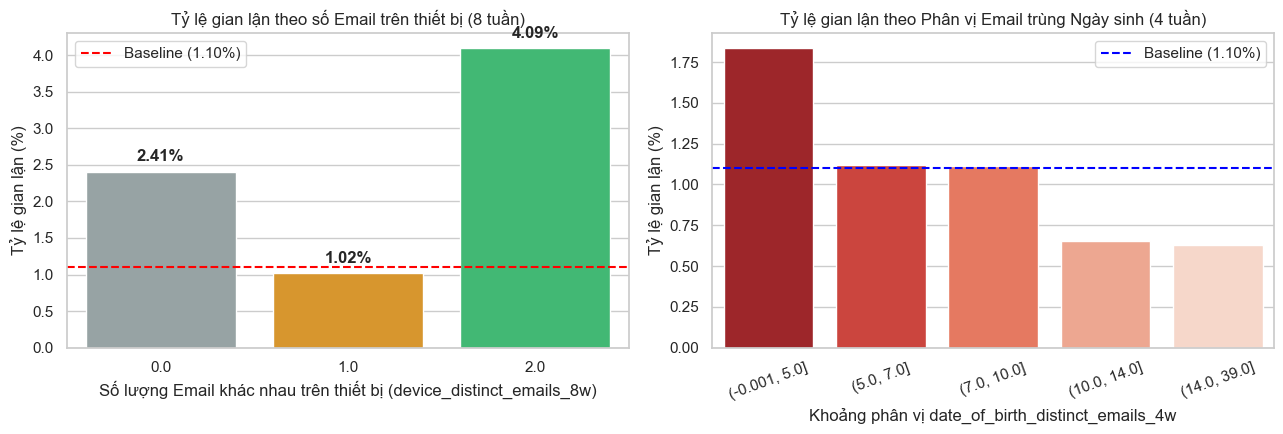

In [35]:
# Trực quan hóa tín hiệu từ thiết bị dùng chung và ngày sinh trùng email
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- axes[0]: device_distinct_emails_8w ---
colors_dev = ['#95A5A6', '#F39C12', '#2ECC71']  # chỉ 3 màu vì có 3 giá trị (0, 1, 2)
x_vals = device_email_stats['device_distinct_emails_8w'].values
y_vals = device_email_stats['Ty_Le_Gian_Lan (%)'].values
bars0 = axes[0].bar(range(len(x_vals)), y_vals, color=colors_dev, edgecolor='white')
axes[0].set_xticks(range(len(x_vals)))
axes[0].set_xticklabels(x_vals)
axes[0].axhline(df[target_col].mean()*100, color='red', linestyle='--', label=f'Baseline ({df[target_col].mean()*100:.2f}%)')
axes[0].set_title("Tỷ lệ gian lận theo số Email trên thiết bị (8 tuần)")
axes[0].set_xlabel("Số lượng Email khác nhau trên thiết bị (device_distinct_emails_8w)")
axes[0].set_ylabel("Tỷ lệ gian lận (%)")
axes[0].legend()
for bar, v in zip(bars0, y_vals):
    axes[0].annotate(f"{v:.2f}%",
                     (bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.1),
                     ha='center', va='bottom', fontweight='bold')

# --- axes[1]: dob_email_bins ---
x_labels = [str(b) for b in dob_stats['dob_email_bins'].values]
y_dob = dob_stats['Ty_Le_Gian_Lan (%)'].values
cmap = plt.cm.Reds_r
colors_dob = [cmap(i / max(len(x_labels) - 1, 1)) for i in range(len(x_labels))]
axes[1].bar(range(len(x_labels)), y_dob, color=colors_dob, edgecolor='white')
axes[1].set_xticks(range(len(x_labels)))
axes[1].set_xticklabels(x_labels, rotation=20, ha='right')
axes[1].axhline(df[target_col].mean()*100, color='blue', linestyle='--', label=f'Baseline ({df[target_col].mean()*100:.2f}%)')
axes[1].set_title("Tỷ lệ gian lận theo Phân vị Email trùng Ngày sinh (4 tuần)")
axes[1].set_xlabel("Khoảng phân vị date_of_birth_distinct_emails_4w")
axes[1].set_ylabel("Tỷ lệ gian lận (%)")
axes[1].legend()

plt.tight_layout()
plt.show()


**Nhận xét:**
- Khi `device_distinct_emails_8w == 2`, tỷ lệ gian lận lên **4.09%**, gấp gần 4 lần mức trung bình. Tuy nhiên theo Information Value (xem 6.3) biến này chỉ ở mức trung bình, thấp hơn nhiều so với `housing_status` hay `credit_risk_score`.
- Với `date_of_birth_distinct_emails_4w`, nhóm giá trị thấp (≤ 5) có tỷ lệ gian lận 1.83%, cao hơn bình thường khoảng 1.8 lần. Ngưỡng cụ thể sẽ được học lại trên Train ở 6.2.


### 4.6 Đặc trưng tài chính

**Hạn mức tín dụng và thẻ khác.** Câu hỏi: kẻ gian có nhắm vào hạn mức cao không, và việc đã có thẻ khác ở cùng ngân hàng (`has_other_cards`) có phải là yếu tố "bảo vệ" không? Nhóm chia `proposed_credit_limit` thành 3 mức (≤ 200, 201–500, > 500).


In [36]:
# Phân nhóm hạn mức tín dụng đề xuất
df['credit_limit_bin'] = pd.cut(
    df['proposed_credit_limit'],
    bins=[0, 200, 500, 2500],
    labels=['Thấp (<=200)', 'Trung bình (201-500)', 'Cao (>500)']
)

limit_risk = df.groupby('credit_limit_bin')[target_col].mean() * 100
cards_risk = df.groupby('has_other_cards')[target_col].mean() * 100

print("Tỷ lệ gian lận theo phân khúc hạn mức tín dụng đề xuất:")
display(limit_risk.round(2))
print()
print("Tỷ lệ gian lận theo cờ đã sở hữu thẻ khác (has_other_cards):")
display(cards_risk.round(2))


Tỷ lệ gian lận theo phân khúc hạn mức tín dụng đề xuất:


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28924\2678447071.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  limit_risk = df.groupby('credit_limit_bin')[target_col].mean() * 100


credit_limit_bin
Thấp (<=200)            0.72
Trung bình (201-500)    1.07
Cao (>500)              2.06
Name: fraud_bool, dtype: float64


Tỷ lệ gian lận theo cờ đã sở hữu thẻ khác (has_other_cards):


has_other_cards
0    1.30
1    0.42
Name: fraud_bool, dtype: float64

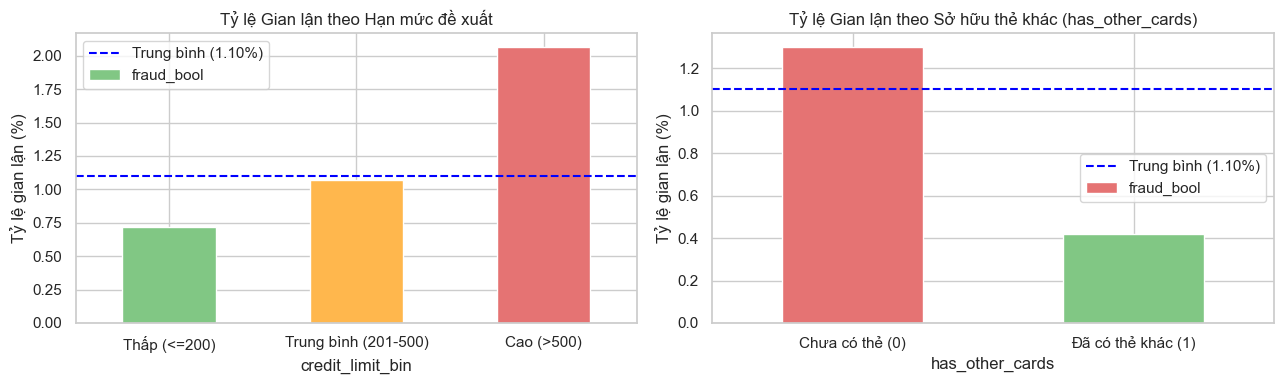

In [37]:
# Trực quan hóa mối liên hệ giữa hạn mức, sở hữu thẻ khác và tỷ lệ gian lận
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 1. Hạn mức tín dụng
limit_risk.plot(kind='bar', ax=axes[0], color=['#81C784', '#FFB74D', '#E57373'])
axes[0].axhline(baseline_fraud, color='blue', linestyle='--', label=f'Trung bình ({baseline_fraud:.2f}%)')
axes[0].set_title("Tỷ lệ Gian lận theo Hạn mức đề xuất")
axes[0].set_ylabel("Tỷ lệ gian lận (%)")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend()

# 2. Sở hữu thẻ khác
cards_risk.plot(kind='bar', ax=axes[1], color=['#E57373', '#81C784'])
axes[1].axhline(baseline_fraud, color='blue', linestyle='--', label=f'Trung bình ({baseline_fraud:.2f}%)')
axes[1].set_title("Tỷ lệ Gian lận theo Sở hữu thẻ khác (has_other_cards)")
axes[1].set_xticklabels(['Chưa có thẻ (0)', 'Đã có thẻ khác (1)'], rotation=0)
axes[1].set_ylabel("Tỷ lệ gian lận (%)")
axes[1].legend()

plt.tight_layout()
plt.show()


**Nhận xét:**
- Ở mức hạn mức người nộp đơn đề xuất thấp nhất (200), tỷ lệ gian lận chỉ **0.72%**; ở hạn mức đề xuất cao (> 500) là **2.06%**, gấp gần 3 lần. Đây là một liên hệ thống kê rõ rệt; có thể kẻ gian cố ý đề xuất hạn mức cao, nhưng dữ liệu không đủ để khẳng định.
- Khách đã có thẻ khác (`has_other_cards = 1`) có tỷ lệ gian lận chỉ **0.42%**, so với **1.30%** ở khách chưa có (thấp hơn khoảng 3.1 lần).


**Điểm rủi ro × hạn mức.** Giả thuyết ban đầu của nhóm là kẻ gian vừa có điểm rủi ro `credit_risk_score` thấp bất thường vừa đề xuất hạn mức cao. Nhóm kiểm tra bằng heatmap và bảng chi tiết kèm N và khoảng tin cậy 95%.

> **Theo [2] (Q7):** `proposed_credit_limit` là **hạn mức do người nộp đơn đề xuất** (*"Applicant's proposed credit limit"*), không phải do ngân hàng. Điều này thay đổi diễn giải: hạn mức cao thể hiện **tham vọng của người nộp đơn**, không phải đánh giá của ngân hàng.


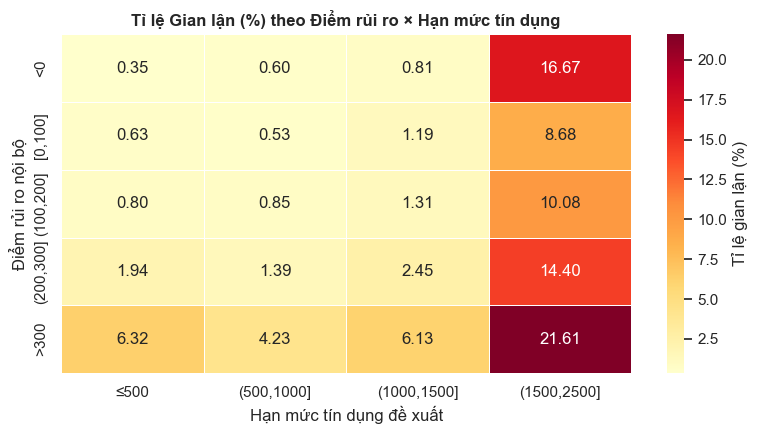

Top 5 phân khúc tương tác rủi ro cao nhất kèm cỡ mẫu và 95% Wilson CI:


,credit_risk_score,proposed_credit_limit,N,Fraud_N,Fraud_Rate,Fraud_Rate (%),95% CI Low (%),95% CI High (%)
19,>300,"(1500,2500]",597,129,0.22,21.61,18.49,25.09
3,<0,"(1500,2500]",18,3,0.17,16.67,5.84,39.22
15,"(200,300]","(1500,2500]",3577,515,0.14,14.40,13.29,15.59
11,"(100,200]","(1500,2500]",1915,193,0.10,10.08,8.81,11.51
7,"[0,100]","(1500,2500]",438,38,0.09,8.68,6.39,11.68


In [38]:
# 1. Phân nhóm điểm rủi ro & hạn mức tín dụng
score_bins = pd.cut(df['credit_risk_score'], bins=[-np.inf, 0, 100, 200, 300, np.inf],
                    labels=['<0', '[0,100]', '(100,200]', '(200,300]', '>300'])
limit_bins = pd.cut(df['proposed_credit_limit'], bins=[0, 500, 1000, 1500, 2500],
                    labels=['≤500', '(500,1000]', '(1000,1500]', '(1500,2500]'])

# 2. Tạo bảng tỉ lệ gian lận (%)
pivot = df.pivot_table(index=score_bins, columns=limit_bins, values=target_col, aggfunc='mean', observed=True) * 100

# 3. Trực quan hóa Heatmap vùng rủi ro
plt.figure(figsize=(8, 4.5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Tỉ lệ gian lận (%)'})
plt.title('Tỉ lệ Gian lận (%) theo Điểm rủi ro × Hạn mức tín dụng', fontweight='bold')
plt.xlabel('Hạn mức tín dụng đề xuất')
plt.ylabel('Điểm rủi ro nội bộ')
plt.tight_layout()
plt.show()

# 4. Bảng thống kê chi tiết kèm Cỡ mẫu N và Khoảng tin cậy 95% Wilson
risk_detail = df.groupby([score_bins, limit_bins], observed=True)[target_col].agg(
    N='count',
    Fraud_N='sum',
    Fraud_Rate='mean'
).reset_index()

ci_low_risk, ci_high_risk = proportion_confint(risk_detail['Fraud_N'], risk_detail['N'], method='wilson')
risk_detail['Fraud_Rate (%)'] = risk_detail['Fraud_Rate'] * 100
risk_detail['95% CI Low (%)'] = ci_low_risk * 100
risk_detail['95% CI High (%)'] = ci_high_risk * 100
risk_detail = risk_detail.sort_values(by='Fraud_Rate (%)', ascending=False)

print("Top 5 phân khúc tương tác rủi ro cao nhất kèm cỡ mẫu và 95% Wilson CI:")
display(risk_detail.head(5).round(2))


**Nhận xét:**
- Ô có tỷ lệ gian lận cao nhất là `credit_risk_score > 300` kết hợp hạn mức 1500–2000: **21.61%** (N = 597, 129 ca gian lận, CI 95%: 18.49%–25.09%). Đây là ô có cỡ mẫu đủ lớn nên khá đáng tin.
- Giả thuyết ban đầu **không được ủng hộ**: ô nguy hiểm nhất nằm ở điểm rủi ro **cao** chứ không phải thấp. Lưu ý rằng `proposed_credit_limit` theo **[2] (Q7)** là hạn mức do **người nộp đơn** đề xuất — kẻ gian có thể cố tình đề xuất hạn mức cao để tối đa hóa số tiền chiếm đoạt được. Ô điểm âm × hạn mức cao có 16.67% nhưng chỉ có N = 18 (CI rất rộng: 5.84%–39.22%), nên không kết luận được.


### 4.7 Tương tác giữa nhà ở và hệ điều hành

**Câu hỏi:** khi kết hợp `device_os` và `housing_status` thì phân khúc nào có rủi ro tập trung cao nhất? Nhóm lập bảng pivot tỷ lệ gian lận và vẽ heatmap, kèm N và CI Wilson 95%.


In [39]:
# Tạo bảng Pivot Table tính tỷ lệ gian lận (%) theo device_os và housing_status
interaction_pivot = df.pivot_table(
    index='housing_status', 
    columns='device_os', 
    values=target_col, 
    aggfunc='mean'
) * 100

print("Bảng tỷ lệ gian lận (%) kết hợp giữa housing_status và device_os:")
display(interaction_pivot.round(2))

# Thống kê độ tin cậy mẫu (Sample Size N, Fraud Count & 95% Wilson Confidence Interval)
from statsmodels.stats.proportion import proportion_confint

inter_stats = df.groupby(['housing_status', 'device_os'], observed=True)[target_col].agg(
    N='count',
    Fraud_N='sum',
    Fraud_Rate='mean'
).reset_index()

ci_low, ci_high = proportion_confint(inter_stats['Fraud_N'], inter_stats['N'], method='wilson')
inter_stats['Fraud_Rate (%)'] = inter_stats['Fraud_Rate'] * 100
inter_stats['95% CI Low (%)'] = ci_low * 100
inter_stats['95% CI High (%)'] = ci_high * 100
inter_stats = inter_stats.sort_values(by='Fraud_Rate (%)', ascending=False)

print("\nTop 5 phân khúc tương tác có tỷ lệ gian lận cao nhất kèm khoảng tin cậy 95% Wilson:")
display(inter_stats.head(5).round(2))


Bảng tỷ lệ gian lận (%) kết hợp giữa housing_status và device_os:


device_os,linux,macintosh,other,windows,x11
housing_status,,,,,
BA,2.00,4.44,1.93,6.76,3.15
BB,0.29,0.97,0.36,1.37,0.53
BC,0.30,0.86,0.32,1.38,0.87
BD,0.43,0.63,0.54,2.08,0.46
BE,0.20,0.43,0.21,0.69,0.56
BF,0.20,1.30,0.28,0.85,0.00
BG,0.00,6.67,0.00,0.00,0.00



Top 5 phân khúc tương tác có tỷ lệ gian lận cao nhất kèm khoảng tin cậy 95% Wilson:


,housing_status,device_os,N,Fraud_N,Fraud_Rate,Fraud_Rate (%),95% CI Low (%),95% CI High (%)
3,BA,windows,57928,3918,0.07,6.76,6.56,6.97
31,BG,macintosh,15,1,0.07,6.67,1.19,29.82
1,BA,macintosh,9525,423,0.04,4.44,4.05,4.87
4,BA,x11,1239,39,0.03,3.15,2.31,4.27
18,BD,windows,6203,129,0.02,2.08,1.75,2.47


Heatmap:


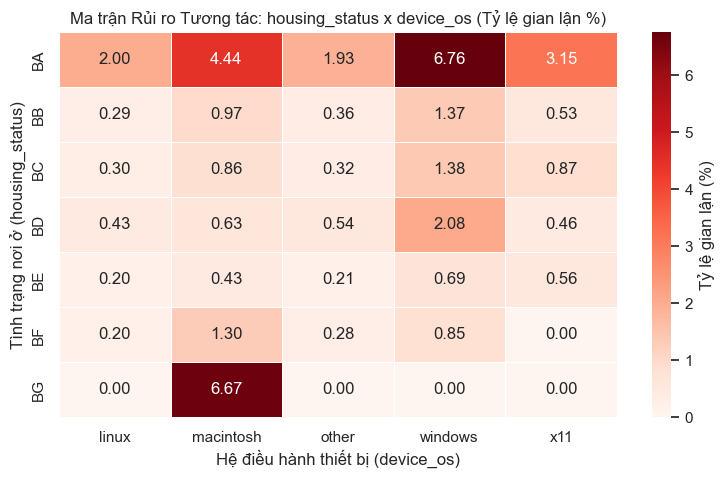

In [40]:
# Biểu đồ Heatmap Ma trận Rủi ro Tương tác
plt.figure(figsize=(9, 5))
sns.heatmap(interaction_pivot, annot=True, fmt='.2f', cmap='Reds', linewidths=0.5, cbar_kws={'label': 'Tỷ lệ gian lận (%)'})
plt.title("Ma trận Rủi ro Tương tác: housing_status x device_os (Tỷ lệ gian lận %)")
plt.xlabel("Hệ điều hành thiết bị (device_os)")
plt.ylabel("Tình trạng nơi ở (housing_status)")
plt.show()


**Nhận xét:**
- Tỷ lệ gian lận trung bình là 1.10%, nhưng ô `BA` × `windows` lên tới **6.76%** (gấp 6.14 lần), với N = 57,928 (CI 95%: 6.56%–6.97%). Đây là ô có bằng chứng vững nhất.
- Ô `BE` × `linux` rất thấp, chỉ **0.20%**.
- Ô `BG` × `macintosh` có 6.67% nhưng chỉ N = 15 (CI 1.19%–29.82%) nên không dùng để kết luận.
- Ma trận có 35 ô và nhóm chọn ô cao nhất sau khi đã xem kết quả, nên khoảng tin cậy có phần lạc quan; cần kiểm chứng lại trên Val/Test.
- Hướng sử dụng: tạo đặc trưng tương tác `housing_status` × `device_os` hoặc để mô hình cây tự học tương tác này.


## 5. Nhân khẩu học và tính công bằng

Theo **[1]** (Section 3, *Protected Attributes*) và **[2] (Q17, Q20)**, bộ dữ liệu BAF có **3 thuộc tính nhạy cảm (protected attributes)**: `customer_age`, `income` và `employment_status`. Trong bài báo gốc, tác giả tập trung vào `customer_age` để tính fairness metrics. Ở giai đoạn EDA nhóm chỉ xem **chênh lệch tỷ lệ gian lận trong dữ liệu** (trước khi có mô hình). Việc đánh giá công bằng của mô hình (FPR ratio, TPR difference giữa các nhóm) sẽ làm ở bước mô hình hóa.

### 5.1 Tỷ lệ gian lận theo tuổi

Theo datasheet `customer_age` đã được làm tròn theo thập kỷ (10, 20, ..., 90). Nhóm gom nhóm theo tuổi và tính số hồ sơ, tỷ lệ gian lận, khoảng tin cậy Wilson và điểm tín dụng trung bình.


In [41]:
# Thống kê số lượng hồ sơ, số ca gian lận, tỷ lệ gian lận và khoảng tin cậy Wilson theo độ tuổi
from statsmodels.stats.proportion import proportion_confint

age_summary = df.groupby('customer_age').agg(
    So_Ho_So=(target_col, 'count'),
    So_Gian_Lan=(target_col, 'sum'),
    Ty_Le_Gian_Lan=(target_col, 'mean'),
    Diem_Tin_Dung_TB=('credit_risk_score', 'mean')
).reset_index()

ci_low_age, ci_high_age = proportion_confint(age_summary['So_Gian_Lan'], age_summary['So_Ho_So'], method='wilson')
age_summary['Tỷ lệ gian lận (%)'] = age_summary['Ty_Le_Gian_Lan'] * 100
age_summary['95% CI Low (%)'] = ci_low_age * 100
age_summary['95% CI High (%)'] = ci_high_age * 100
age_summary['Độ tuổi'] = age_summary['customer_age'].astype(str) + ' tuổi'
display(age_summary[['Độ tuổi', 'So_Ho_So', 'So_Gian_Lan', 'Tỷ lệ gian lận (%)', '95% CI Low (%)', '95% CI High (%)', 'Diem_Tin_Dung_TB']].round(2))


,Độ tuổi,So_Ho_So,So_Gian_Lan,Tỷ lệ gian lận (%),95% CI Low (%),95% CI High (%),Diem_Tin_Dung_TB
0,10 tuổi,20987,74,0.35,0.28,0.44,110.66
1,20 tuổi,245855,1205,0.49,0.46,0.52,113.60
2,30 tuổi,311433,2589,0.83,0.80,0.86,129.39
3,40 tuổi,238712,2876,1.20,1.16,1.25,139.85
4,50 tuổi,140353,2805,2.00,1.93,2.07,149.96
5,60 tuổi,34770,1149,3.30,3.12,3.50,141.42
6,70 tuổi,6517,263,4.04,3.58,4.54,138.96
7,80 tuổi,1297,64,4.93,3.88,6.25,137.98
8,90 tuổi,76,4,5.26,2.07,12.77,153.53


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28924\2614606134.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_summary, x='Độ tuổi', y='Tỷ lệ gian lận (%)', palette='YlOrRd')


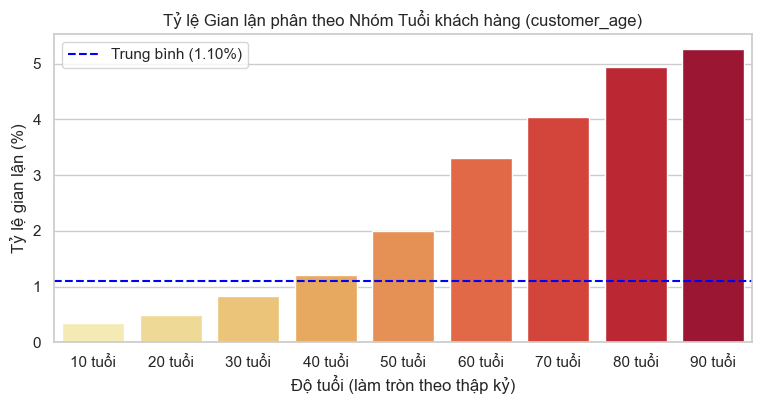

In [42]:
# Biểu đồ tỷ lệ gian lận theo nhóm tuổi
plt.figure(figsize=(9, 4))
sns.barplot(data=age_summary, x='Độ tuổi', y='Tỷ lệ gian lận (%)', hue='Độ tuổi', palette='YlOrRd', legend=False)
plt.axhline(baseline_fraud, color='blue', linestyle='--', linewidth=1.5, label=f'Trung bình ({baseline_fraud:.2f}%)')
plt.title("Tỷ lệ Gian lận phân theo Nhóm Tuổi khách hàng (customer_age)")
plt.xlabel("Độ tuổi (làm tròn theo thập kỷ)")
plt.ylabel("Tỷ lệ gian lận (%)")
plt.legend()
plt.show()


**Nhận xét:** tỷ lệ gian lận tăng dần theo tuổi:
- Nhóm 10 tuổi: **0.35%** (N = 20,987); nhóm 20 tuổi: **0.49%** (N = 245,855).
- Nhóm 40 tuổi: **1.20%**, bắt đầu vượt mức trung bình 1.10%.
- Nhóm 60 tuổi: **3.30%** (N = 34,770).
- Nhóm 80 và 90 tuổi: **4.93%** và **5.26%**, nhưng nhóm 90 chỉ có N = 76 (CI 95%: 2.07%–12.77%), nên chỉ mang tính tham khảo.

Đây là **mối liên hệ thống kê**, chưa nói được nguyên nhân. Một giả thuyết thường gặp là giả mạo danh tính của người lớn tuổi có lịch sử tín dụng dài, nhưng dữ liệu không đủ để kiểm chứng.


### 5.2 Hai nhóm tuổi (< 50 và ≥ 50)

Theo **[1]** (Section 3): *"we create a categorical version by separating applicants with age >50 in one group and ≤50 in the other group"*. **[2] (Q17)**: *"With the selected threshold we obtain approximately 80% of the applications in the former group and 20% of the applications in the latter. The latter group has a prevalence of fraud approximately two times superior to the former."* Nhóm làm tương tự và so sánh số hồ sơ, tỷ lệ gian lận.


In [43]:
# Phân nhóm tuổi nhạy cảm theo chuẩn NeurIPS 2022 (<50 vs >=50)
df['age_protected_group'] = np.where(df['customer_age'] < 50, '< 50 tuổi', '>= 50 tuổi')

# Thống kê số lượng hồ sơ và tỷ lệ gian lận theo nhóm tuổi bảo vệ
fairness_summary = df.groupby('age_protected_group').agg(
    Tong_Ho_So=(target_col, 'count'),
    So_Gian_Lan=(target_col, 'sum'),
    Ty_Le_Gian_Lan=(target_col, 'mean')
).reset_index()

fairness_summary['Ty_Le_Ho_So (%)'] = fairness_summary['Tong_Ho_So'] / len(df) * 100
fairness_summary['Ty_Le_Gian_Lan (%)'] = fairness_summary['Ty_Le_Gian_Lan'] * 100
fairness_summary


,age_protected_group,Tong_Ho_So,So_Gian_Lan,Ty_Le_Gian_Lan,Ty_Le_Ho_So (%),Ty_Le_Gian_Lan (%)
0,< 50 tuổi,816987,6744,0.008255,81.6987,0.825472
1,>= 50 tuổi,183013,4285,0.023414,18.3013,2.341364


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28924\3207108445.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='age_protected_group', palette=['#3498DB', '#E67E22'], ax=axes[0])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28924\3207108445.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fairness_summary, x='age_protected_group', y='Ty_Le_Gian_Lan (%)',


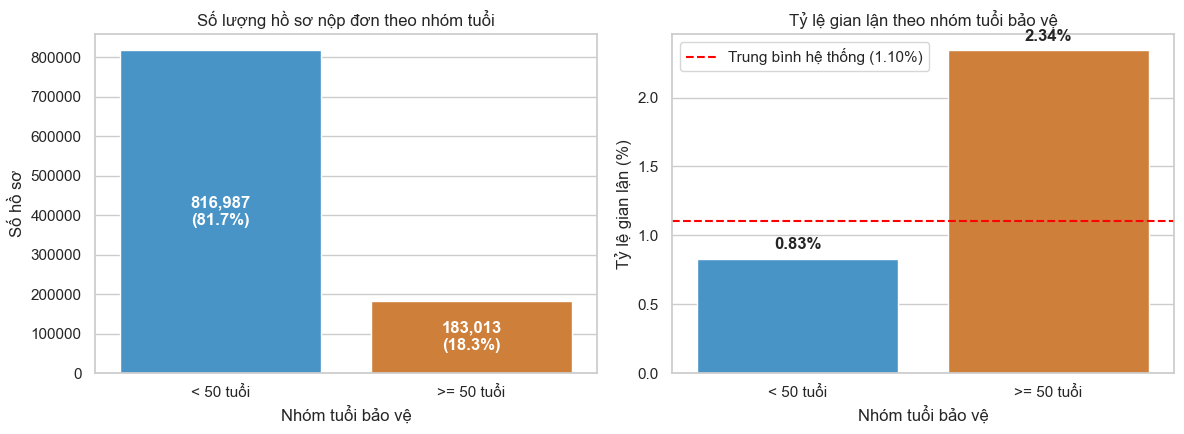

In [44]:
# Trực quan hóa phân phối hồ sơ và mức chênh lệch tỷ lệ gian lận giữa 2 nhóm tuổi
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.countplot(data=df, x='age_protected_group', hue='age_protected_group',
              palette=['#3498DB', '#E67E22'], ax=axes[0], legend=False)
axes[0].set_title("Số lượng hồ sơ nộp đơn theo nhóm tuổi")
axes[0].set_xlabel("Nhóm tuổi bảo vệ")
axes[0].set_ylabel("Số hồ sơ")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}\n({p.get_height()/len(df)*100:.1f}%)", 
                     (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', va='center', color='white', fontweight='bold')

sns.barplot(data=fairness_summary, x='age_protected_group', y='Ty_Le_Gian_Lan (%)',
            hue='age_protected_group', palette=['#3498DB', '#E67E22'], ax=axes[1], legend=False)
axes[1].axhline(df[target_col].mean()*100, color='red', linestyle='--', label=f'Trung bình hệ thống ({df[target_col].mean()*100:.2f}%)')
axes[1].set_title("Tỷ lệ gian lận theo nhóm tuổi bảo vệ")
axes[1].set_xlabel("Nhóm tuổi bảo vệ")
axes[1].set_ylabel("Tỷ lệ gian lận (%)")
axes[1].legend()
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f}%", 
                     (p.get_x() + p.get_width() / 2., p.get_height() + 0.05),
                     ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


**Nhận xét:**
- Nhóm `< 50` chiếm 81.70% hồ sơ, nhóm `≥ 50` chỉ chiếm 18.30%.
- Tỷ lệ gian lận ở nhóm `≥ 50` là **2.34%**, cao gấp **2.84 lần** nhóm `< 50` (**0.83%**), nhất quán với xu hướng ở 5.1.
- Theo **[1]** (Section 3.3, *Prevalence disparity*): *"fraudsters have an incentive to impersonate older people: banks provide older applicants with larger lines of credit once an account is opened, which fraudsters try to max out before being caught."* Đây là giải thích hợp lý nhất cho tỷ lệ gian lận cao hơn ở nhóm tuổi ≥50.

Hệ quả cho bước mô hình: vì nhãn lịch sử ở nhóm cao tuổi có tỷ lệ gian lận cao hơn, mô hình có thể gán xác suất rủi ro cao hơn cho người lớn tuổi và từ chối nhầm nhiều khách hợp pháp ở nhóm này (FPR cao hơn). Khi có mô hình, cần theo dõi FPR ratio và TPR difference giữa hai nhóm tuổi thay vì chỉ nhìn độ chính xác tổng.


### 5.3 Thu nhập và nghề nghiệp

Tương tự, nhóm xem tỷ lệ gian lận theo thu nhập (`income`) và tình trạng nghề nghiệp (`employment_status`), rồi tính tỷ số chênh lệch (disparity ratio) giữa nhóm cao nhất và thấp nhất.

(Lưu ý nhỏ: biểu đồ cột chia thu nhập thành các khoảng (0, 0.3], (0.3, 0.6], (0.6, 1.0], còn bảng tỷ số dùng `income ≥ 0.6` cho nhóm cao nên hai con số của nhóm cao có thể lệch nhau một chút.)


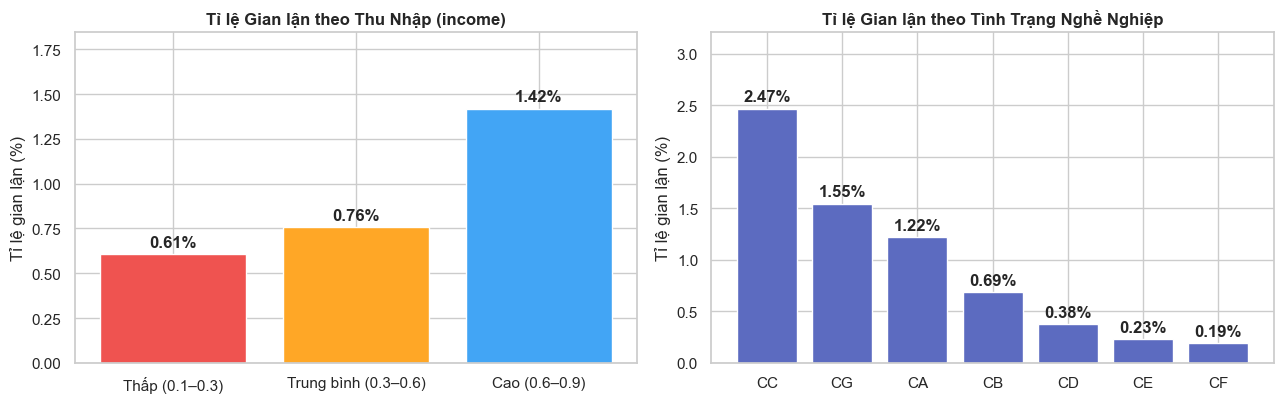

,Protected Attribute,Nhóm rủi ro cao,Fraud Rate (Cao),Nhóm rủi ro thấp,Fraud Rate (Thấp),Disparity Ratio
0,customer_age (<50 vs ≥50),≥ 50 tuổi,2.34%,< 50 tuổi,0.83%,2.84×
1,income (Thấp vs Cao),Thu nhập cao (≥0.6),1.42%,Thu nhập thấp (≤0.3),0.61%,2.34×
2,employment_status (CC vs CF),CC,2.47%,CF,0.19%,12.79×


In [45]:
# 1. Trực quan hóa tỉ lệ gian lận theo Thu nhập & Nghề nghiệp
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

# Thu nhập (income)
inc_group = pd.cut(df['income'], bins=[0, 0.3, 0.6, 1.0], labels=['Thấp (0.1–0.3)', 'Trung bình (0.3–0.6)', 'Cao (0.6–0.9)'])
inc_rate = df.groupby(inc_group, observed=True)[target_col].mean() * 100
bars1 = axes[0].bar(inc_rate.index, inc_rate.values, color=['#EF5350', '#FFA726', '#42A5F5'], edgecolor='white')
axes[0].bar_label(bars1, fmt='%.2f%%', padding=3, fontweight='bold')
axes[0].set(title='Tỉ lệ Gian lận theo Thu Nhập (income)', ylabel='Tỉ lệ gian lận (%)', ylim=(0, inc_rate.max() * 1.3))
axes[0].title.set_fontweight('bold')

# Nghề nghiệp (employment_status)
emp_rate = (df.groupby('employment_status', observed=True)[target_col].mean() * 100).sort_values(ascending=False)
bars2 = axes[1].bar(emp_rate.index, emp_rate.values, color='#5C6BC0', edgecolor='white')
axes[1].bar_label(bars2, fmt='%.2f%%', padding=3, fontweight='bold')
axes[1].set(title='Tỉ lệ Gian lận theo Tình Trạng Nghề Nghiệp', ylabel='Tỉ lệ gian lận (%)', ylim=(0, emp_rate.max() * 1.3))
axes[1].title.set_fontweight('bold')

plt.tight_layout()
plt.show()

# 2. Bảng tóm tắt Disparity Ratio (Chênh lệch rủi ro giữa các nhóm nhạy cảm)
rate_age_lo = df.loc[df['customer_age'] < 50, target_col].mean()
rate_age_hi = df.loc[df['customer_age'] >= 50, target_col].mean()
rate_inc_lo = df.loc[df['income'] <= 0.3, target_col].mean()
rate_inc_hi = df.loc[df['income'] >= 0.6, target_col].mean()
top_emp, bot_emp = emp_rate.index[0], emp_rate.index[-1]
rate_emp_hi, rate_emp_lo = emp_rate.iloc[0] / 100, emp_rate.iloc[-1] / 100

disparity_df = pd.DataFrame({
    'Protected Attribute': ['customer_age (<50 vs ≥50)', 'income (Thấp vs Cao)', f'employment_status ({top_emp} vs {bot_emp})'],
    'Nhóm rủi ro cao': ['≥ 50 tuổi', 'Thu nhập cao (≥0.6)', f'{top_emp}'],
    'Fraud Rate (Cao)': [f"{rate_age_hi*100:.2f}%", f"{rate_inc_hi*100:.2f}%", f"{rate_emp_hi*100:.2f}%"],
    'Nhóm rủi ro thấp': ['< 50 tuổi', 'Thu nhập thấp (≤0.3)', f'{bot_emp}'],
    'Fraud Rate (Thấp)': [f"{rate_age_lo*100:.2f}%", f"{rate_inc_lo*100:.2f}%", f"{rate_emp_lo*100:.2f}%"],
    'Disparity Ratio': [f"{rate_age_hi/rate_age_lo:.2f}×", f"{rate_inc_hi/rate_inc_lo:.2f}×", f"{rate_emp_hi/rate_emp_lo:.2f}×"]
})
display(disparity_df)


**Nhận xét:**
- **Thu nhập:** tỷ lệ gian lận tăng theo thu nhập: nhóm cao (≥ 0.6) khoảng **1.42%**, gấp **2.34 lần** nhóm thấp (≤ 0.3, **0.61%**); nhóm giữa khoảng **0.76%**. Nếu mô hình dựa nhiều vào thu nhập thì khách hợp pháp thu nhập cao dễ bị từ chối nhầm hơn.
- **Nghề nghiệp:** từ **0.19%** (nhóm `CF`) đến **2.47%** (nhóm `CC`), chênh lệch khoảng 12.8 lần. Quyết định từ chối dựa vào nghề nghiệp có thể gây bất bình đẳng trong tiếp cận dịch vụ, nên cần kiểm soát.


> **Fairness metric theo [1]** (Section 3, *Fairness Metric*): Metric đánh giá công bằng chính thức là **FPR ratio** (*predictive equality*) — tỷ số FPR giữa hai nhóm tuổi. Mục tiêu: tỷ số càng gần 1 càng tốt. Trong bài báo, các mô hình LightGBM tốt nhất trên tập Base có FPR ratio ≈ **0.3**, tức là nhóm ≥50 bị từ chối nhầm nhiều hơn nhóm <50 hơn 3 lần (**[1]**, Section 4).
